# Low cardinality, multiple entities to match

In [1]:
import pandas as pd

import os, sys

# ---- 1️⃣ Find the directory that holds the `em_pipeline` package ----
# Start from the notebook’s directory (or the current working directory)
start = os.path.abspath(os.getcwd())
if "__file__" in globals():                     # works when run as a script
    start = os.path.abspath(os.path.dirname(__file__))

# Walk up the tree until we see a folder called `em_pipeline`
repo_root = start
while True:
    if os.path.isdir(os.path.join(repo_root, "em_pipeline")):
        break                                   # we found it
    parent = os.path.dirname(repo_root)
    if parent == repo_root:                     # reached filesystem root → give up
        raise RuntimeError("Could not find a directory containing 'em_pipeline'")
    repo_root = parent

# ---- 2️⃣ Insert it at the front of sys.path (if not already there) ----
if repo_root not in sys.path:
    sys.path.insert(0, repo_root)


from em_pipeline.data_loader import (
    load_pair_dfs_from_paths, 
    standardise_dt, 
    plot_numerical_distribution,
)
from em_pipeline.splink_helper import (
    build_api_with_con,
    get_blocking_rules,
    get_estimating_blocking_rules,
    get_numerical_comparison,
    get_datetime_comparison,
    get_category_comparison,
    train_linker,
    visualise_data,
)
from splink import DuckDBAPI, Linker, SettingsCreator

In [2]:
DF1_PATH = os.path.join("..", "..", "output_data", "low_card_dataset_a.parquet")
DF2_PATH = os.path.join("..", "..", "output_data", "low_card_dataset_b.parquet")

# DuckDB resource limits (same as in the original notebook)
MEM_LIMIT  = "'24GB'"
TEMP_DIR   = "'./duckdb_spill_dir.tmp'"

# Column names used in the synthetic dataset
LEFT_ID_COL   = "local_source_id"      # appears in both df1 & df2 after loading
RIGHT_ID_COL  = "local_source_id"
UNIQUE_ID_COL = "latent_event_id"      # used for labeling / de‑duplication
CATEGORICAL_COL   = "categorical"
DATETIME_COL      = "datetime_noisy"

# How strict we want the initial random‑match estimate to be
RECALL_FOR_PRIOR = 0.99   # same as the original notebook

In [3]:
df1, df2 = load_pair_dfs_from_paths(DF1_PATH, DF2_PATH)
print(f"cartesian prod: {len(df1) * len(df2)}")

cartesian prod: 2304168


In [4]:
standardise_dt(df1, df2, DATETIME_COL)

Set datetime_noisy to date for both df1 and df2.


In [5]:
from splink.exploratory import profile_columns

db_api = build_api_with_con(MEM_LIMIT, TEMP_DIR)

profile_columns(
    [df1, df2],
    db_api=db_api,
    column_expressions=[
        "categorical",
        "datetime_noisy",
    ],
)

alt.VConcatChart(...)

In [6]:
from splink.blocking_analysis import (
    cumulative_comparisons_to_be_scored_from_blocking_rules_chart
)

# Rule 1: Match on category OR allow if either side is missing
blocking_rule_category = """
    l.categorical = r.categorical 
    OR l.categorical IS NULL 
    OR r.categorical IS NULL
"""

blocking_rule_day = """
    strftime(l.datetime_noisy, '%Y%m%d') = strftime(r.datetime_noisy, '%Y%m%d')
    OR l.datetime_noisy IS NULL 
    OR r.datetime_noisy IS NULL
"""

blocking_rule_date_shift_1 = """
    strftime(CAST(l.datetime_noisy AS TIMESTAMP) + INTERVAL '1' DAY, '%Y%m') = strftime(CAST(r.datetime_noisy AS TIMESTAMP), '%Y%m')
    OR l.datetime_noisy IS NULL 
    OR r.datetime_noisy IS NULL
"""

blocking_rule_date_shift_2 = """
    strftime(CAST(l.datetime_noisy AS TIMESTAMP) - INTERVAL '1' DAY, '%Y%m') = strftime(CAST(r.datetime_noisy AS TIMESTAMP), '%Y%m')
    OR l.datetime_noisy IS NULL 
    OR r.datetime_noisy IS NULL
"""

brs = [
    blocking_rule_category,
    blocking_rule_day,
    blocking_rule_date_shift_1,
    blocking_rule_date_shift_2
]

cumulative_comparisons_to_be_scored_from_blocking_rules_chart(
    table_or_tables=[df1, df2],
    blocking_rules=brs,
    db_api=db_api,
    link_type="link_only",
    unique_id_column_name="latent_event_id"
)

alt.Chart(...)

In [7]:
import splink.comparison_level_library as cll
import splink.comparison_library as cl

# We retain the same comparison levels.
base_template = f"abs(date_diff('day', {DATETIME_COL}_l, {DATETIME_COL}_r))"
within_n_days_template = base_template + " <= {n}"


datetime_noisy_comparison = {
    "output_column_name": DATETIME_COL,
    "comparison_levels": [
        cll.NullLevel(DATETIME_COL),
        {
            "sql_condition": within_n_days_template.format(n=0),
            "label_for_charts": "Same day",
        },
        {
            "sql_condition": within_n_days_template.format(n=1),
            "label_for_charts": "<=1 day",
        },
        cll.ElseLevel(),
    ],
    "comparison_description": "Datetime days apart",
}

categorical_comparison = get_category_comparison(cat_col=CATEGORICAL_COL)

settings = SettingsCreator(
    link_type="link_only", 
    unique_id_column_name="latent_event_id",
    blocking_rules_to_generate_predictions=brs,
    comparisons=[
        categorical_comparison,
        datetime_noisy_comparison
    ],
    max_iterations=100,
    em_convergence=0.0001,
    retain_intermediate_calculation_columns=True,
    additional_columns_to_retain=["local_source_id", "global_entity_id"],
)

linker = Linker(
    [df1, df2],
    settings,
    db_api=db_api
)

In [8]:
strict_rule_category = "l.categorical = r.categorical"

# Rule 3: Datetime is within 1 day (24 hours) of each other
strict_rule_datetime = """
    ABS(
        epoch(CAST(l.datetime_noisy AS TIMESTAMP)) - 
        epoch(CAST(r.datetime_noisy AS TIMESTAMP))
    ) <= 86400
"""

datetime_full = strict_rule_category + " AND " + strict_rule_datetime

strict_training_rules = [
    datetime_full,
]

linker.training.estimate_probability_two_random_records_match(
    datetime_full, recall=0.99
)

Probability two random records match is estimated to be  0.0221.
This means that amongst all possible pairwise record comparisons, one in 45.21 are expected to match.  With 2,304,168 total possible comparisons, we expect a total of around 50,966.67 matching pairs


In [9]:
linker.training.estimate_u_using_random_sampling(max_pairs=1e8)

----- Estimating u probabilities using random sampling -----

Estimated u probabilities using random sampling

Your model is not yet fully trained. Missing estimates for:
    - categorical (no m values are trained).
    - datetime_noisy (no m values are trained).


In [10]:
linker.training.estimate_parameters_using_expectation_maximisation(
    "abs(epoch(l.datetime_noisy::TIMESTAMP) - epoch(r.datetime_noisy::TIMESTAMP)) <= 0",
)


----- Starting EM training session -----

Estimating the m probabilities of the model by blocking on:
abs(epoch(l.datetime_noisy::TIMESTAMP) - epoch(r.datetime_noisy::TIMESTAMP)) <= 0

Parameter estimates will be made for the following comparison(s):
    - categorical

Parameter estimates cannot be made for the following comparison(s) since they are used in the blocking rules: 
    - datetime_noisy

Iteration 1: Largest change in params was 0.00215 in the m_probability of categorical, level `All other comparisons`
Iteration 2: Largest change in params was -0.0022 in the m_probability of categorical, level `Exact match on categorical`
Iteration 3: Largest change in params was 0.00224 in the m_probability of categorical, level `All other comparisons`
Iteration 4: Largest change in params was 0.00228 in the m_probability of categorical, level `All other comparisons`
Iteration 5: Largest change in params was -0.00232 in the m_probability of categorical, level `Exact match on categorical`


<EMTrainingSession, blocking on abs(epoch(l.datetime_noisy::TIMESTAMP) - epoch(r.datetime_noisy::TIMESTAMP)) <= 0, deactivating comparisons datetime_noisy>

In [11]:
from splink import block_on

linker.training.estimate_parameters_using_expectation_maximisation(block_on("categorical"))


----- Starting EM training session -----

Estimating the m probabilities of the model by blocking on:
l."categorical" = r."categorical"

Parameter estimates will be made for the following comparison(s):
    - datetime_noisy

Parameter estimates cannot be made for the following comparison(s) since they are used in the blocking rules: 
    - categorical

Iteration 1: Largest change in params was -0.072 in the m_probability of datetime_noisy, level `Same day`
Iteration 2: Largest change in params was -0.0613 in the m_probability of datetime_noisy, level `Same day`
Iteration 3: Largest change in params was -0.0527 in the m_probability of datetime_noisy, level `Same day`
Iteration 4: Largest change in params was -0.0458 in the m_probability of datetime_noisy, level `Same day`
Iteration 5: Largest change in params was -0.0401 in the m_probability of datetime_noisy, level `Same day`
Iteration 6: Largest change in params was -0.0354 in the m_probability of datetime_noisy, level `Same day`
Ite

<EMTrainingSession, blocking on l."categorical" = r."categorical", deactivating comparisons categorical>

In [12]:
linker.visualisations.match_weights_chart()

/home/local/KLASS/steven.zhu/miniconda3/envs/GlobalEM/lib/python3.11/site-packages/altair/vegalite/v6/api.py:4138: UserWarning: Automatically deduplicated selection parameter with identical configuration. If you want independent parameters, explicitly name them differently (e.g., name='param1', name='param2'). See https://github.com/vega/altair/issues/3891
  return _tp.from_dict(dct, validate=validate)


alt.VConcatChart(...)

In [13]:
df_predict = linker.inference.predict()

Blocking time: 1.63 seconds
Predict time: 0.47 seconds


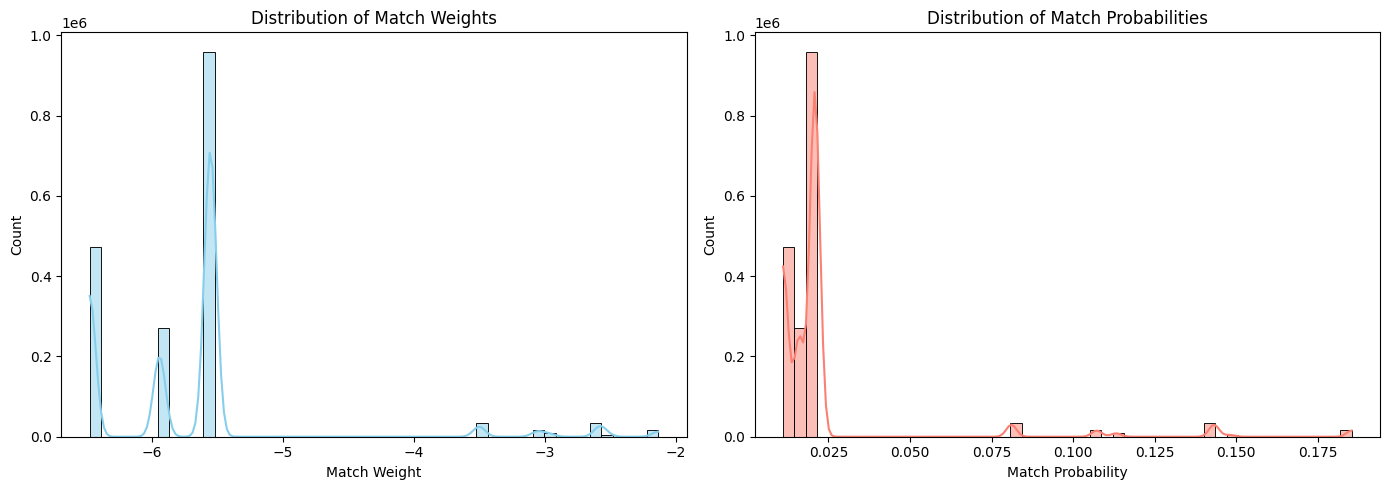

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure the Splink object is converted to a Pandas DataFrame
df_pandas = df_predict.as_pandas_dataframe()

# Create a two-panel distribution plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Panel 1: Match Weight Distribution (Linear scale, e.g., -10 to +30)
sns.histplot(data=df_pandas, x="match_weight", bins=50, ax=axes[0], color="skyblue", kde=True)
axes[0].set_title("Distribution of Match Weights")
axes[0].set_xlabel("Match Weight")

# Panel 2: Match Probability Distribution (S-curve squeezed between 0 and 1)
sns.histplot(data=df_pandas, x="match_probability", bins=50, ax=axes[1], color="salmon", kde=True)
axes[1].set_title("Distribution of Match Probabilities")
axes[1].set_xlabel("Match Probability")

plt.tight_layout()
plt.show()


In [15]:
# We want to do the following analysis: check the distribution of match probabilities for pairs where the latent_event_id matches vs. those where it does not match.
df_predict_pd = df_predict.as_pandas_dataframe()

matches = df_predict_pd[df_predict_pd["latent_event_id_l"] == df_predict_pd["latent_event_id_r"]]
non_matches = df_predict_pd[df_predict_pd["latent_event_id_l"] != df_predict_pd["latent_event_id_r"]]

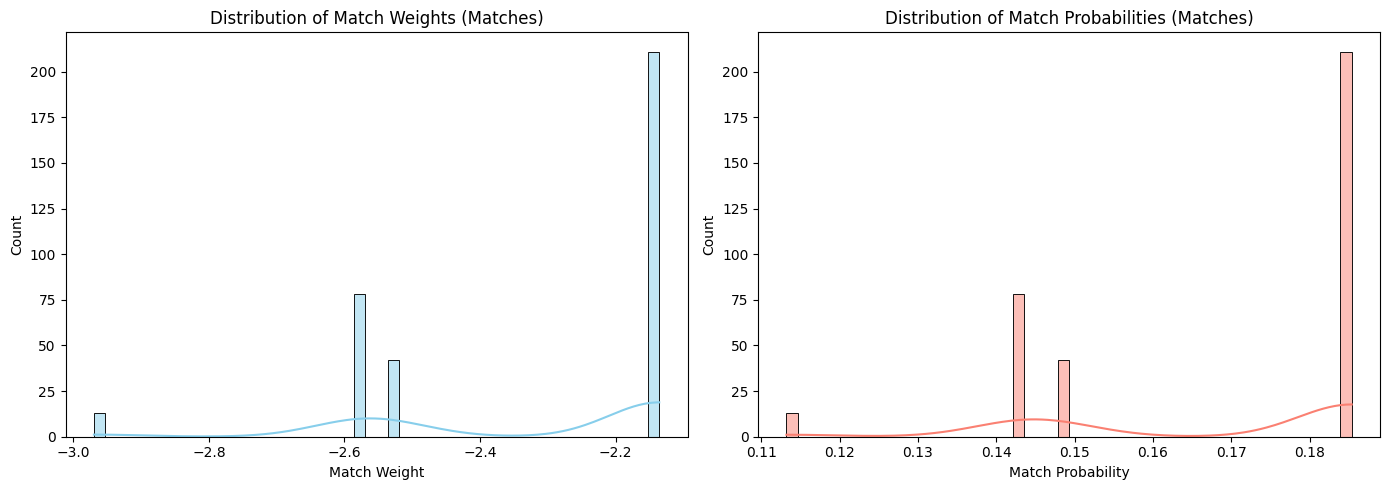

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Panel 1: Match Weight Distribution
sns.histplot(data=matches, x="match_weight", bins=50, ax=axes[0], color="skyblue", kde=True)
axes[0].set_title("Distribution of Match Weights (Matches)")
axes[0].set_xlabel("Match Weight")

# Panel 2: Match Probability Distribution (S-curve squeezed between 0 and 1)
sns.histplot(data=matches, x="match_probability", bins=50, ax=axes[1], color="salmon", kde=True)
axes[1].set_title("Distribution of Match Probabilities (Matches)")
axes[1].set_xlabel("Match Probability")

plt.tight_layout()
plt.show()

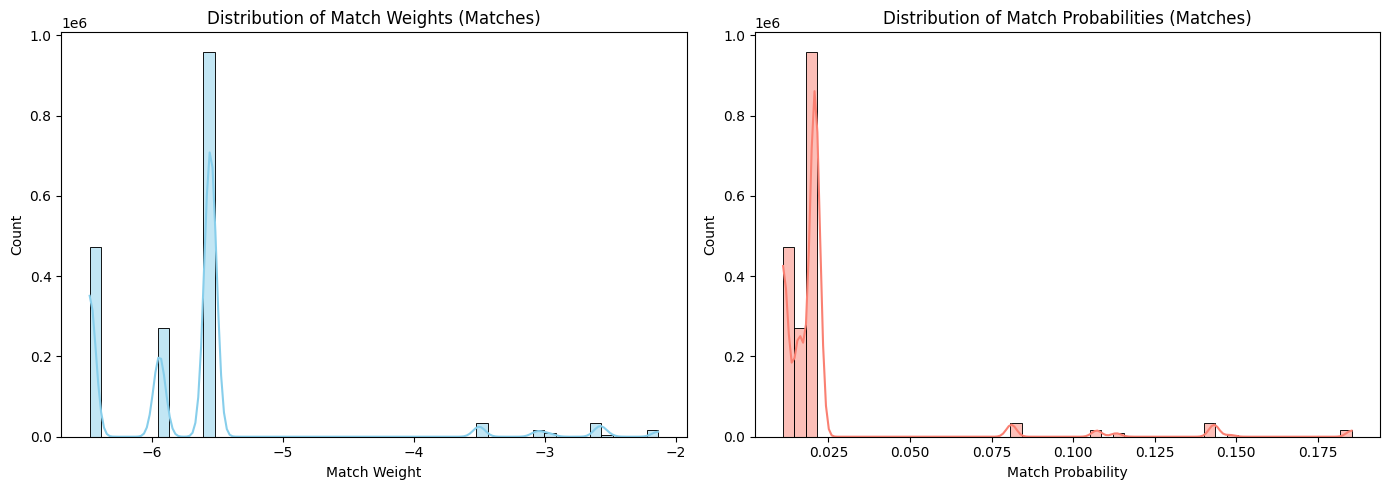

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Panel 1: Match Weight Distribution
sns.histplot(data=non_matches, x="match_weight", bins=50, ax=axes[0], color="skyblue", kde=True)
axes[0].set_title("Distribution of Match Weights (Matches)")
axes[0].set_xlabel("Match Weight")

# Panel 2: Match Probability Distribution (S-curve squeezed between 0 and 1)
sns.histplot(data=non_matches, x="match_probability", bins=50, ax=axes[1], color="salmon", kde=True)
axes[1].set_title("Distribution of Match Probabilities (Matches)")
axes[1].set_xlabel("Match Probability")

plt.tight_layout()
plt.show()

In [18]:
import pandas as pd

# ==========================================
# STEP 1: Discover Splink's Internal Dataset Names
# ==========================================
# Get the exact keys Splink uses internally to label the left and right datasets
dataset_names = list(linker._input_tables_dict.keys())
print(f"DEBUG: Splink recognizes your datasets as: {dataset_names}")

# Assign them cleanly based on their registration sequence
internal_name_df1 = dataset_names[0]
internal_name_df2 = dataset_names[1]


# ==========================================
# STEP 2: Standardise and Extract Common Identifiers
# ==========================================
# Get common IDs and ensure they are read purely as identical string types
ids_df1 = df1[['latent_event_id']].copy().rename(columns={'latent_event_id': 'latent_event_id_l'})
ids_df2 = df2[['latent_event_id']].copy().rename(columns={'latent_event_id': 'latent_event_id_r'})

raw_matches = ids_df1.merge(ids_df2, left_on='latent_event_id_l', right_on='latent_event_id_r')


# ==========================================
# STEP 3: Enforce Exact Splink Alphabetical Left-Right Sort Order
# ==========================================
labels_df = pd.DataFrame()
labels_df["latent_event_id_l"] = raw_matches["latent_event_id_l"]
labels_df["latent_event_id_r"] = raw_matches["latent_event_id_r"]
labels_df["source_dataset_l"] = internal_name_df1
labels_df["source_dataset_r"] = internal_name_df2
labels_df["clerical_match_score"] = 1.0

# Splink drops labels if concat(source_l, id_l) > concat(source_r, id_r)
concat_l = labels_df["source_dataset_l"] + "-__-" + labels_df["latent_event_id_l"]
concat_r = labels_df["source_dataset_r"] + "-__-" + labels_df["latent_event_id_r"]
swap_mask = concat_l > concat_r

if swap_mask.any():
    # Correct source datasets orientation
    labels_df.loc[swap_mask, ["source_dataset_l", "source_dataset_r"]] = \
        labels_df.loc[swap_mask, ["source_dataset_r", "source_dataset_l"]].values
    # Correct corresponding ID orientation
    labels_df.loc[swap_mask, ["latent_event_id_l", "latent_event_id_r"]] = \
        labels_df.loc[swap_mask, ["latent_event_id_r", "latent_event_id_l"]].values


# ==========================================
# STEP 4: Safely Overwrite and Register Table Pointers
# ==========================================
try:
    linker.misc.query_sql("DROP TABLE IF EXISTS my_ground_truth_labels")
except Exception:
    pass

labels_table = linker.table_management.register_labels_table(labels_df, overwrite=True)
print(f"Success: Registered {len(labels_df)} ground-truth rows with Splink's structural format.")


# ==========================================
# STEP 5: Force Prediction & Extract Accuracy Metrics
# ==========================================
# Ensure a prediction pass has run so intermediate tables are active
print("Calculating link pairs...")
pred = linker.inference.predict() 

# Extract the metrics
try:
    roc_metrics_df = linker.evaluation.accuracy_analysis_from_labels_table(
        labels_table, 
        output_type="table",
        add_metrics=["f1", "accuracy"]
    ).as_pandas_dataframe()
    
    print(f"Evaluation succeeded! Rows generated: {len(roc_metrics_df)}")
except Exception as err:
    print(f"Failed during evaluation compilation: {err}")


'CREATE TABLE __splink__df_sql_query_81245833c AS 
DROP TABLE IF EXISTS my_ground_truth_labels' contains unsupported syntax. Falling back to parsing as a 'Command'.


DEBUG: Splink recognizes your datasets as: ['__splink__input_table_0', '__splink__input_table_1']
Success: Registered 344 ground-truth rows with Splink's structural format.
Calculating link pairs...


Blocking time: 1.69 seconds
Predict time: 0.07 seconds


Evaluation succeeded! Rows generated: 4


In [19]:
linker.evaluation.accuracy_analysis_from_labels_table(
    labels_table, 
    add_metrics=["f1", "accuracy"],
    output_type="threshold_selection"
)


alt.HConcatChart(...)

In [20]:
left_counts  = df1["local_source_id"].value_counts()   # Series: id → frequency in df1
right_counts = df2["local_source_id"].value_counts()   # Series: id → frequency in df2

agg_df = (
    df_predict_pd[
        ['local_source_id_l', 'local_source_id_r','match_probability']
    ]
    .groupby(['local_source_id_l', 'local_source_id_r'], as_index=False)
    .agg({'match_probability': sum})
)

agg_df

/tmp/ipykernel_1380701/3828851778.py:9: FutureWarning: The provided callable <built-in function sum> is currently using SeriesGroupBy.sum. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "sum" instead.
  .agg({'match_probability': sum})


,local_source_id_l,local_source_id_r,match_probability
0,DF1_100000,DF1_100007,2.480203
1,DF1_100000,DF1_100020,2.004896
2,DF1_100000,DF1_100025,1.122856
3,DF1_100000,DF1_100037,4.934407
4,DF1_100000,DF1_100038,3.162560
...,...,...,...
9995,DF1_100179,DF2_100164,5.802602
9996,DF1_100179,DF2_100165,4.886369
9997,DF1_100179,DF2_100166,2.972107
9998,DF1_100179,DF2_100167,5.802383


In [21]:
unique_l = left_counts.index
unique_r = right_counts.index

# Cartesian product of the observed ids (still a DataFrame)
pair_keys = pd.MultiIndex.from_product(
    [unique_l, unique_r],
    names=["local_source_id_l", "local_source_id_r"]
).to_frame(index=False)

# Attach the left and right counts
pair_keys = pair_keys.merge(
    left_counts.rename("left_count"),
    left_on="local_source_id_l",
    right_index=True,
    how="left"
).merge(
    right_counts.rename("right_count"),
    left_on="local_source_id_r",
    right_index=True,
    how="left"
)

# Pair‑specific denominator = left_count × right_count
pair_keys["pair_size"] = pair_keys["left_count"] * pair_keys["right_count"]

# -------------------------------------------------
# 4️⃣  Join the aggregated probabilities to the pair‑specific sizes
# -------------------------------------------------
norm_df = pair_keys.merge(
    agg_df,
    on=["local_source_id_l", "local_source_id_r"],
    how="left"               # keep all pairs; missing probabilities become NaN
)

norm_df["norm_match_prob"] = norm_df["match_probability"] / norm_df["pair_size"]

norm_df

,local_source_id_l,local_source_id_r,left_count,right_count,pair_size,match_probability,norm_match_prob
0,DF1_100037,DF1_100037,35,35,1225,27.324891,0.022306
1,DF1_100037,DF1_100151,35,29,1015,19.969591,0.019674
2,DF1_100037,DF1_100038,35,24,840,15.815944,0.018829
3,DF1_100037,DF1_100178,35,23,805,15.595940,0.019374
4,DF1_100037,DF2_100055,35,22,770,14.331211,0.018612
...,...,...,...,...,...,...,...
9995,DF1_100173,DF2_100144,1,5,5,0.073640,0.014728
9996,DF1_100173,DF2_100140,1,4,4,0.027116,0.006779
9997,DF1_100173,DF2_100065,1,4,4,0.073640,0.018410
9998,DF1_100173,DF2_100040,1,4,4,0.062526,0.015631


In [22]:
norm_df[norm_df['local_source_id_l'] == norm_df['local_source_id_r']]

,local_source_id_l,local_source_id_r,left_count,right_count,pair_size,match_probability,norm_match_prob
0,DF1_100037,DF1_100037,35,35,1225,27.324891,0.022306
601,DF1_100151,DF1_100151,29,29,841,20.543128,0.024427
1402,DF1_100038,DF1_100038,24,24,576,13.609211,0.023627
1903,DF1_100178,DF1_100178,23,23,529,14.619102,0.027635
2405,DF1_100007,DF1_100007,21,21,441,10.201242,0.023132
3206,DF1_100089,DF1_100089,20,20,400,11.052739,0.027632
4713,DF1_100177,DF1_100177,19,19,361,10.438145,0.028915
4910,DF1_100066,DF1_100066,19,19,361,11.238266,0.031131
5118,DF1_100050,DF1_100050,18,18,324,8.226785,0.025391
5321,DF1_100123,DF1_100123,17,17,289,10.060295,0.034811


In [23]:
norm_df[norm_df['local_source_id_l'] != norm_df['local_source_id_r']].sort_values(by = "norm_match_prob", ascending=False)

,local_source_id_l,local_source_id_r,left_count,right_count,pair_size,match_probability,norm_match_prob
9963,DF1_100173,DF1_100025,1,11,11,0.451524,0.041048
9660,DF1_100078,DF2_100105,6,11,66,2.151998,0.032606
9388,DF1_100079,DF2_100030,8,8,64,2.038490,0.031851
9587,DF1_100131,DF2_100142,7,8,56,1.779426,0.031775
9584,DF1_100131,DF2_100136,7,8,56,1.732310,0.030934
...,...,...,...,...,...,...,...
9973,DF1_100173,DF2_100163,1,10,10,0.084754,0.008475
9986,DF1_100173,DF2_100118,1,8,8,0.063913,0.007989
9996,DF1_100173,DF2_100140,1,4,4,0.027116,0.006779
9944,DF1_100173,DF1_100020,1,13,13,0.084754,0.006520


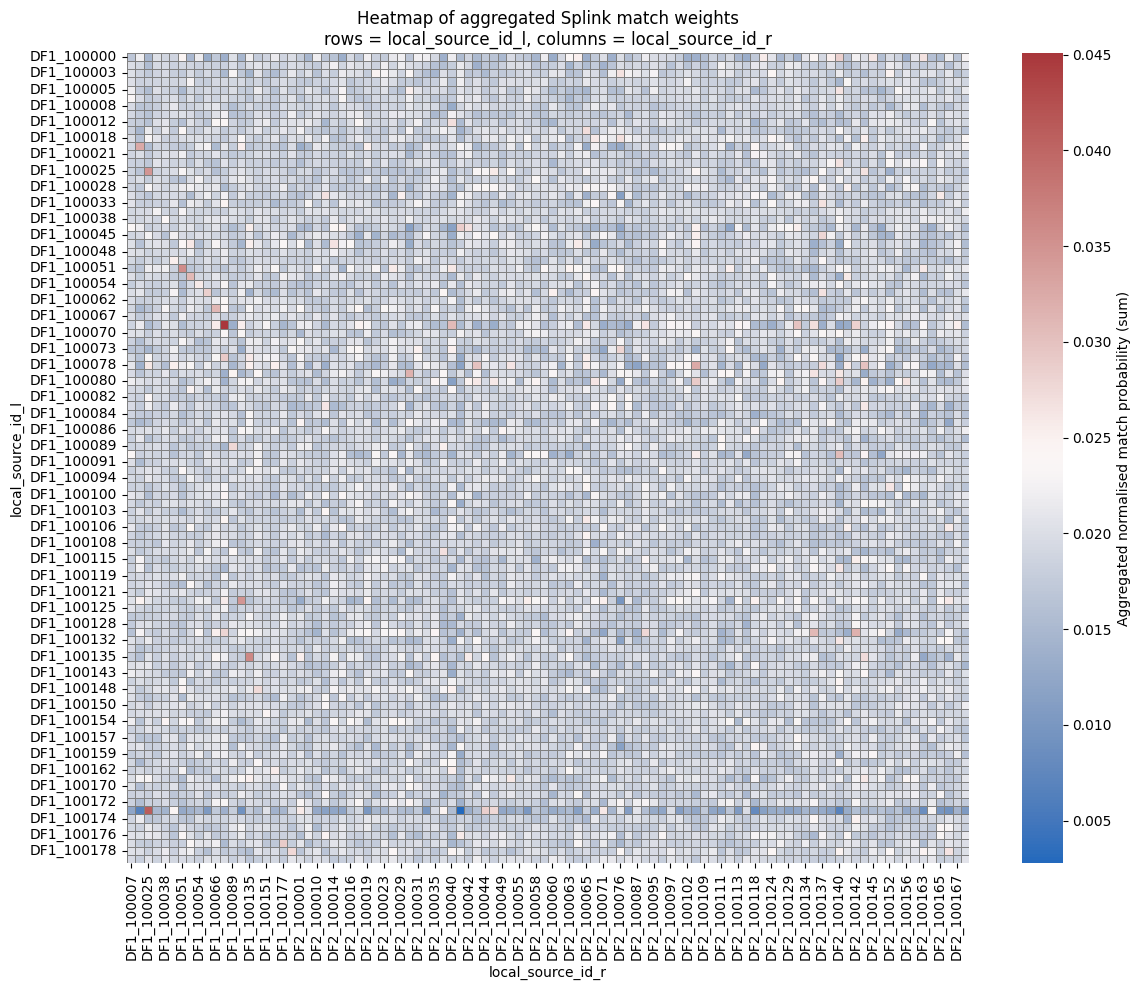

In [24]:
mat = norm_df.pivot(
    index = 'local_source_id_l',
    columns = 'local_source_id_r',
    values = 'norm_match_prob'
)

plt.figure(figsize=(12, 10))
sns.heatmap(
    mat,
    cmap='vlag',           # diverging colormap; change if you prefer another
    mask=mat.isna(),       # hide missing cells (pairs with no observations)
    linewidths=.5,
    linecolor='gray',
    cbar_kws={'label': 'Aggregated normalised match probability (sum)'}
)
plt.title('Heatmap of aggregated Splink match weights\n'
          'rows = local_source_id_l, columns = local_source_id_r')
plt.xlabel('local_source_id_r')
plt.ylabel('local_source_id_l')
plt.tight_layout()
plt.show()

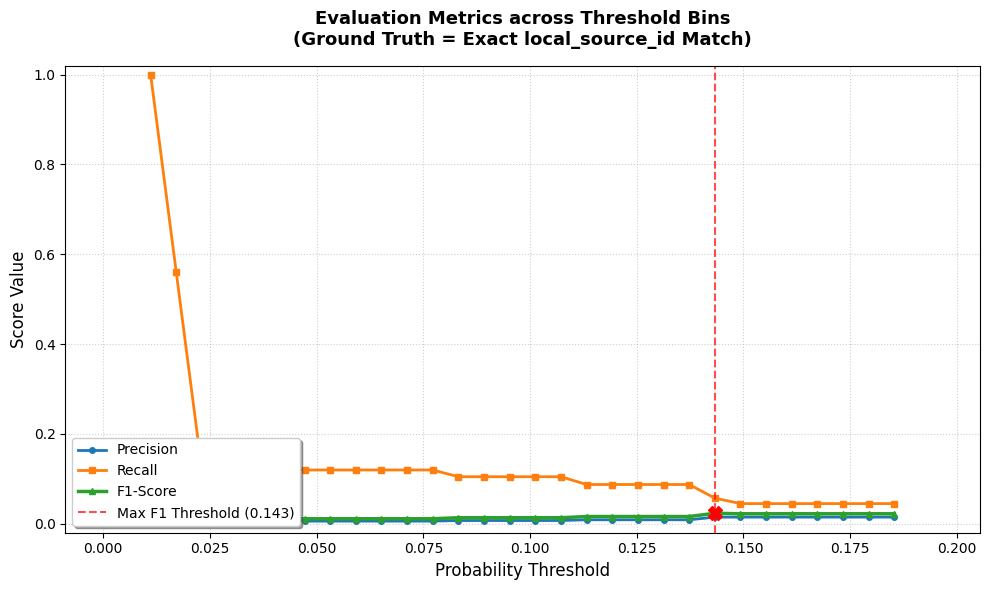

Optimal Threshold: 0.1433 yields the highest F1-Score of 0.0233


In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_fscore_support

# 1. Create the ground truth column (1 if source IDs are an exact match, else 0)
df_predict_pd['is_exact_match'] = (
    df_predict_pd['local_source_id_l'] == df_predict_pd['local_source_id_r']
).astype(int)

# --- Configuration ---
ground_truth_col = 'is_exact_match'
prob_col = 'match_probability'

# 2. Generate 30 threshold bins from min to max probability
min_prob = df_predict_pd[prob_col].min()
max_prob = df_predict_pd[prob_col].max()
thresholds = np.linspace(min_prob, max_prob, 30)

# 3. Initialize arrays to store metric scores
precisions = []
recalls = []
f1_scores = []

y_true = df_predict_pd[ground_truth_col]

# 4. Calculate metrics for each threshold bin
for t in thresholds:
    # Binarise predictions based on the current threshold
    y_pred = (df_predict_pd[prob_col] >= t).astype(int)
    
    # Calculate precision, recall, and F1 for the positive class (1)
    p, r, f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average='binary', zero_division=0
    )
    
    precisions.append(p)
    recalls.append(r)
    f1_scores.append(f1)

# 5. Find the optimal threshold that maximises the F1-score
best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]
best_f1 = f1_scores[best_idx]

# 6. Plot the evaluation curves
plt.figure(figsize=(10, 6))

plt.plot(thresholds, precisions, label='Precision', color='#1f77b4', linewidth=2, marker='o', markersize=4)
plt.plot(thresholds, recalls, label='Recall', color='#ff7f0e', linewidth=2, marker='s', markersize=4)
plt.plot(thresholds, f1_scores, label='F1-Score', color='#2ca02c', linewidth=2.5, marker='^', markersize=5)

# Visual anchors for the best F1-score
plt.axvline(x=best_threshold, color='red', linestyle='--', alpha=0.7, 
            label=f'Max F1 Threshold ({best_threshold:.3f})')
plt.plot(best_threshold, best_f1, color='red', marker='X', markersize=10)

# Formatting
plt.title('Evaluation Metrics across Threshold Bins\n(Ground Truth = Exact local_source_id Match)', fontsize=13, fontweight='bold', pad=15)
plt.xlabel('Probability Threshold', fontsize=12)
plt.ylabel('Score Value', fontsize=12)
plt.xlim(min_prob - 0.02, max_prob + 0.02)
plt.ylim(-0.02, 1.02)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(loc='lower left', frameon=True, shadow=True)
plt.tight_layout()

plt.show()

print(f"Optimal Threshold: {best_threshold:.4f} yields the highest F1-Score of {best_f1:.4f}")


### Attempting other methods

In [26]:
U_BASE = linker._settings_obj._probability_two_random_records_match
left_counts = df1["local_source_id"].value_counts()
right_counts = df2["local_source_id"].value_counts()
EPSILON = 1e-6

import numpy as np
import pandas as pd

# Assume U_BASE, left_counts, right_counts, and EPSILON are predefined as in your setup

def calc_noisy_or(probs):
    # Clips to avoid negative or undefined log1p results if an edge hit exactly 1.0
    probs_clamped = np.clip(np.array(probs), 0.0, 1.0 - 1e-12)
    return 1.0 - np.exp(np.sum(np.log1p(-probs_clamped)))

def calc_softmax_prob(probs):
    """
    Computes a soft-maximum probability. 
    Highlights individual high-confidence transaction signals without collapsing to hard max.
    """
    p_arr = np.array(probs)
    if len(p_arr) == 0:
        return 0.0
    # Use max substraction trick to prevent overflow
    e_p = np.exp(p_arr - np.max(p_arr))
    return np.sum(p_arr * (e_p / np.sum(e_p)))

def calc_top_k_mean_weight(weights, k=3):
    """
    Calculates the mean of the top K highest match weights.
    Protects against low-weight noise from routine/ubiquitous transactions.
    """
    w_arr = np.array(weights)
    if len(w_arr) == 0:
        return 0.0
    top_k = np.sort(w_arr)[-k:]  # Extracts up to the top K weights
    return np.mean(top_k)

# --- Process Aggregations ---
agg_df = (
    df_predict_pd[
        ['local_source_id_l', 'local_source_id_r', 'match_probability', 'match_weight']
    ]
    .groupby(["local_source_id_l", "local_source_id_r"], as_index=False, dropna=False)
    .agg(
        sum_p=("match_probability", "sum"),
        max_w=("match_weight", "max"),
        top_3_mean_w=("match_weight", lambda w: calc_top_k_mean_weight(w, k=3)),
        observed_edges=("match_probability", "count"),
        score_noisy_or=("match_probability", calc_noisy_or),
        score_softmax_p=("match_probability", calc_softmax_prob),
        # Need to capture raw first values to anchor mapped sizing later
        _id_l=("local_source_id_l", "first"),
        _id_r=("local_source_id_r", "first"),
    )
)

# --- Map Source Sizes and Structural Metrics ---
agg_df["size_l"] = agg_df["_id_l"].map(left_counts).fillna(1)
agg_df["size_r"] = agg_df["_id_r"].map(right_counts).fillna(1)
agg_df = agg_df.drop(columns=["_id_l", "_id_r"])  # Clean up temporary grouping anchors

agg_df["max_possible_pairs"] = agg_df["size_l"] * agg_df["size_r"]
agg_df["match_density"] = agg_df["sum_p"] / agg_df["max_possible_pairs"]

# --- New Structural Overlap Metrics ---
# Weighted Jaccard: Intersection mass over Union mass
agg_df["weighted_jaccard"] = agg_df["sum_p"] / (agg_df["size_l"] + agg_df["size_r"] - agg_df["sum_p"] + EPSILON)

# Weighted Overlap: Intersection mass normalized by the smaller entity profile size
agg_df["weighted_overlap_coef"] = agg_df["sum_p"] / (np.minimum(agg_df["size_l"], agg_df["size_r"]) + EPSILON)

# --- Baseline Ratios ---
agg_df["expected_random_matches"] = agg_df["max_possible_pairs"] * U_BASE
agg_df["score_prob_expected_ratio"] = np.log(
    (agg_df["sum_p"] + EPSILON) / (agg_df["expected_random_matches"] + EPSILON)
)

# Final Clean Up
agg_df = agg_df.drop(columns=["expected_random_matches"]).sort_values(by="max_possible_pairs", ascending=False)


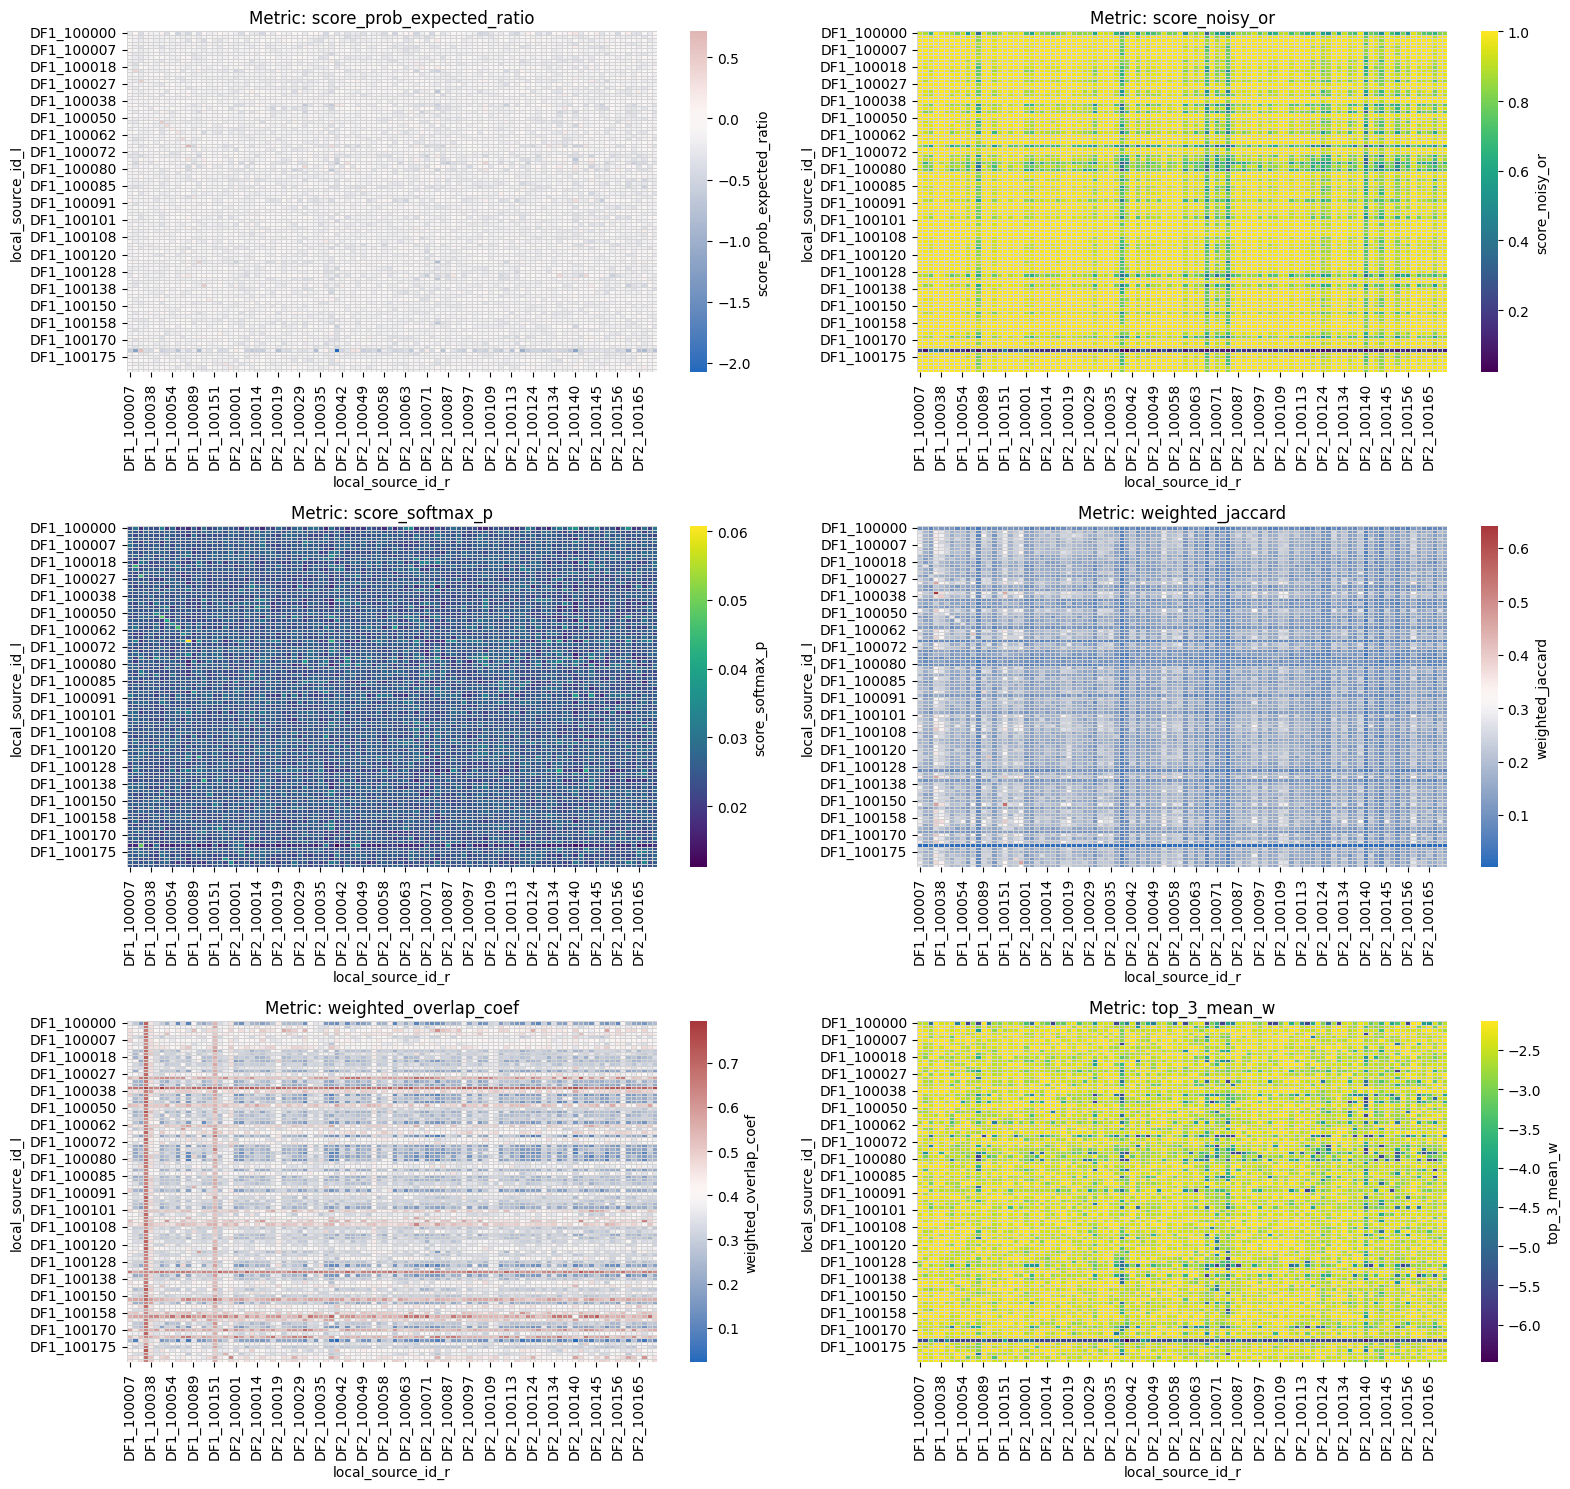

In [27]:
import math
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Define all the score columns you want to visualize
score_cols = [
    "score_prob_expected_ratio",
    "score_noisy_or",
    "score_softmax_p",
    "weighted_jaccard",
    "weighted_overlap_coef",
    "top_3_mean_w",
]

# 2. Dynamically calculate grid layout dimensions (2 columns wide)
n_metrics = len(score_cols)
n_cols = 2
n_rows = math.ceil(n_metrics / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 5 * n_rows))
axes = axes.flatten()  # Flatten into a 1D array for easier iteration

# 3. Loop through each metric and plot its respective heatmap
for idx, col in enumerate(score_cols):
    ax = axes[idx]

    # Create the pivot matrix for this specific metric
    mat = agg_df.pivot(
        index="local_source_id_l", columns="local_source_id_r", values=col
    )

    # Determine colormap style based on the metric's data distribution
    # Diverging maps ('vlag') are great for ratios with negative values. 
    # Sequential maps ('Viridis') are better for strict 0-1 probabilities.
    if "ratio" in col or "weight" in col:
        cmap_choice = "vlag"
        center_val = 0.0 if mat.min().min() < 0 else None
    else:
        cmap_choice = "viridis"
        center_val = None

    # Plot the heatmap on its designated subplot axis
    sns.heatmap(
        mat,
        cmap=cmap_choice,
        center=center_val,
        mask=mat.isna(),  # Hide missing evaluation pairs safely
        linewidths=0.5,
        linecolor="lightgray",
        cbar_kws={"label": col},
        ax=ax,
    )

    ax.set_title(f"Metric: {col}")
    ax.set_xlabel("local_source_id_r")
    ax.set_ylabel("local_source_id_l")

# 4. Hide any unused trailing subplot frames in the grid layout
for idx in range(n_metrics, len(axes)):
    fig.delaxes(axes[idx])

plt.tight_layout()
plt.show()


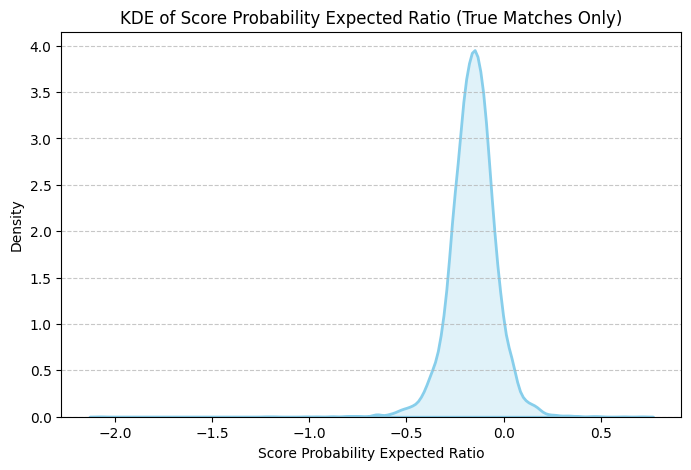

In [28]:
agg_df["is_true_match"] = (agg_df["local_source_id_l"] == agg_df["local_source_id_r"]).astype(int)

agg_df[agg_df["is_true_match"] == 1]["score_prob_expected_ratio"]

import matplotlib.pyplot as plt
import seaborn as sns

# Filter the data for true matches
true_matches_ratio = agg_df["score_prob_expected_ratio"]

# Option 1: Using Seaborn (Recommended for smooth aesthetics)
plt.figure(figsize=(8, 5))
sns.kdeplot(data=true_matches_ratio, fill=True, color="skyblue", linewidth=2)
plt.title("KDE of Score Probability Expected Ratio (True Matches Only)")
plt.xlabel("Score Probability Expected Ratio")
plt.ylabel("Density")
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.show()

# Option 2: Using Pandas native plotting (Quickest)
# true_matches_ratio.plot(kind="kde", figsize=(8, 5))
# plt.show()


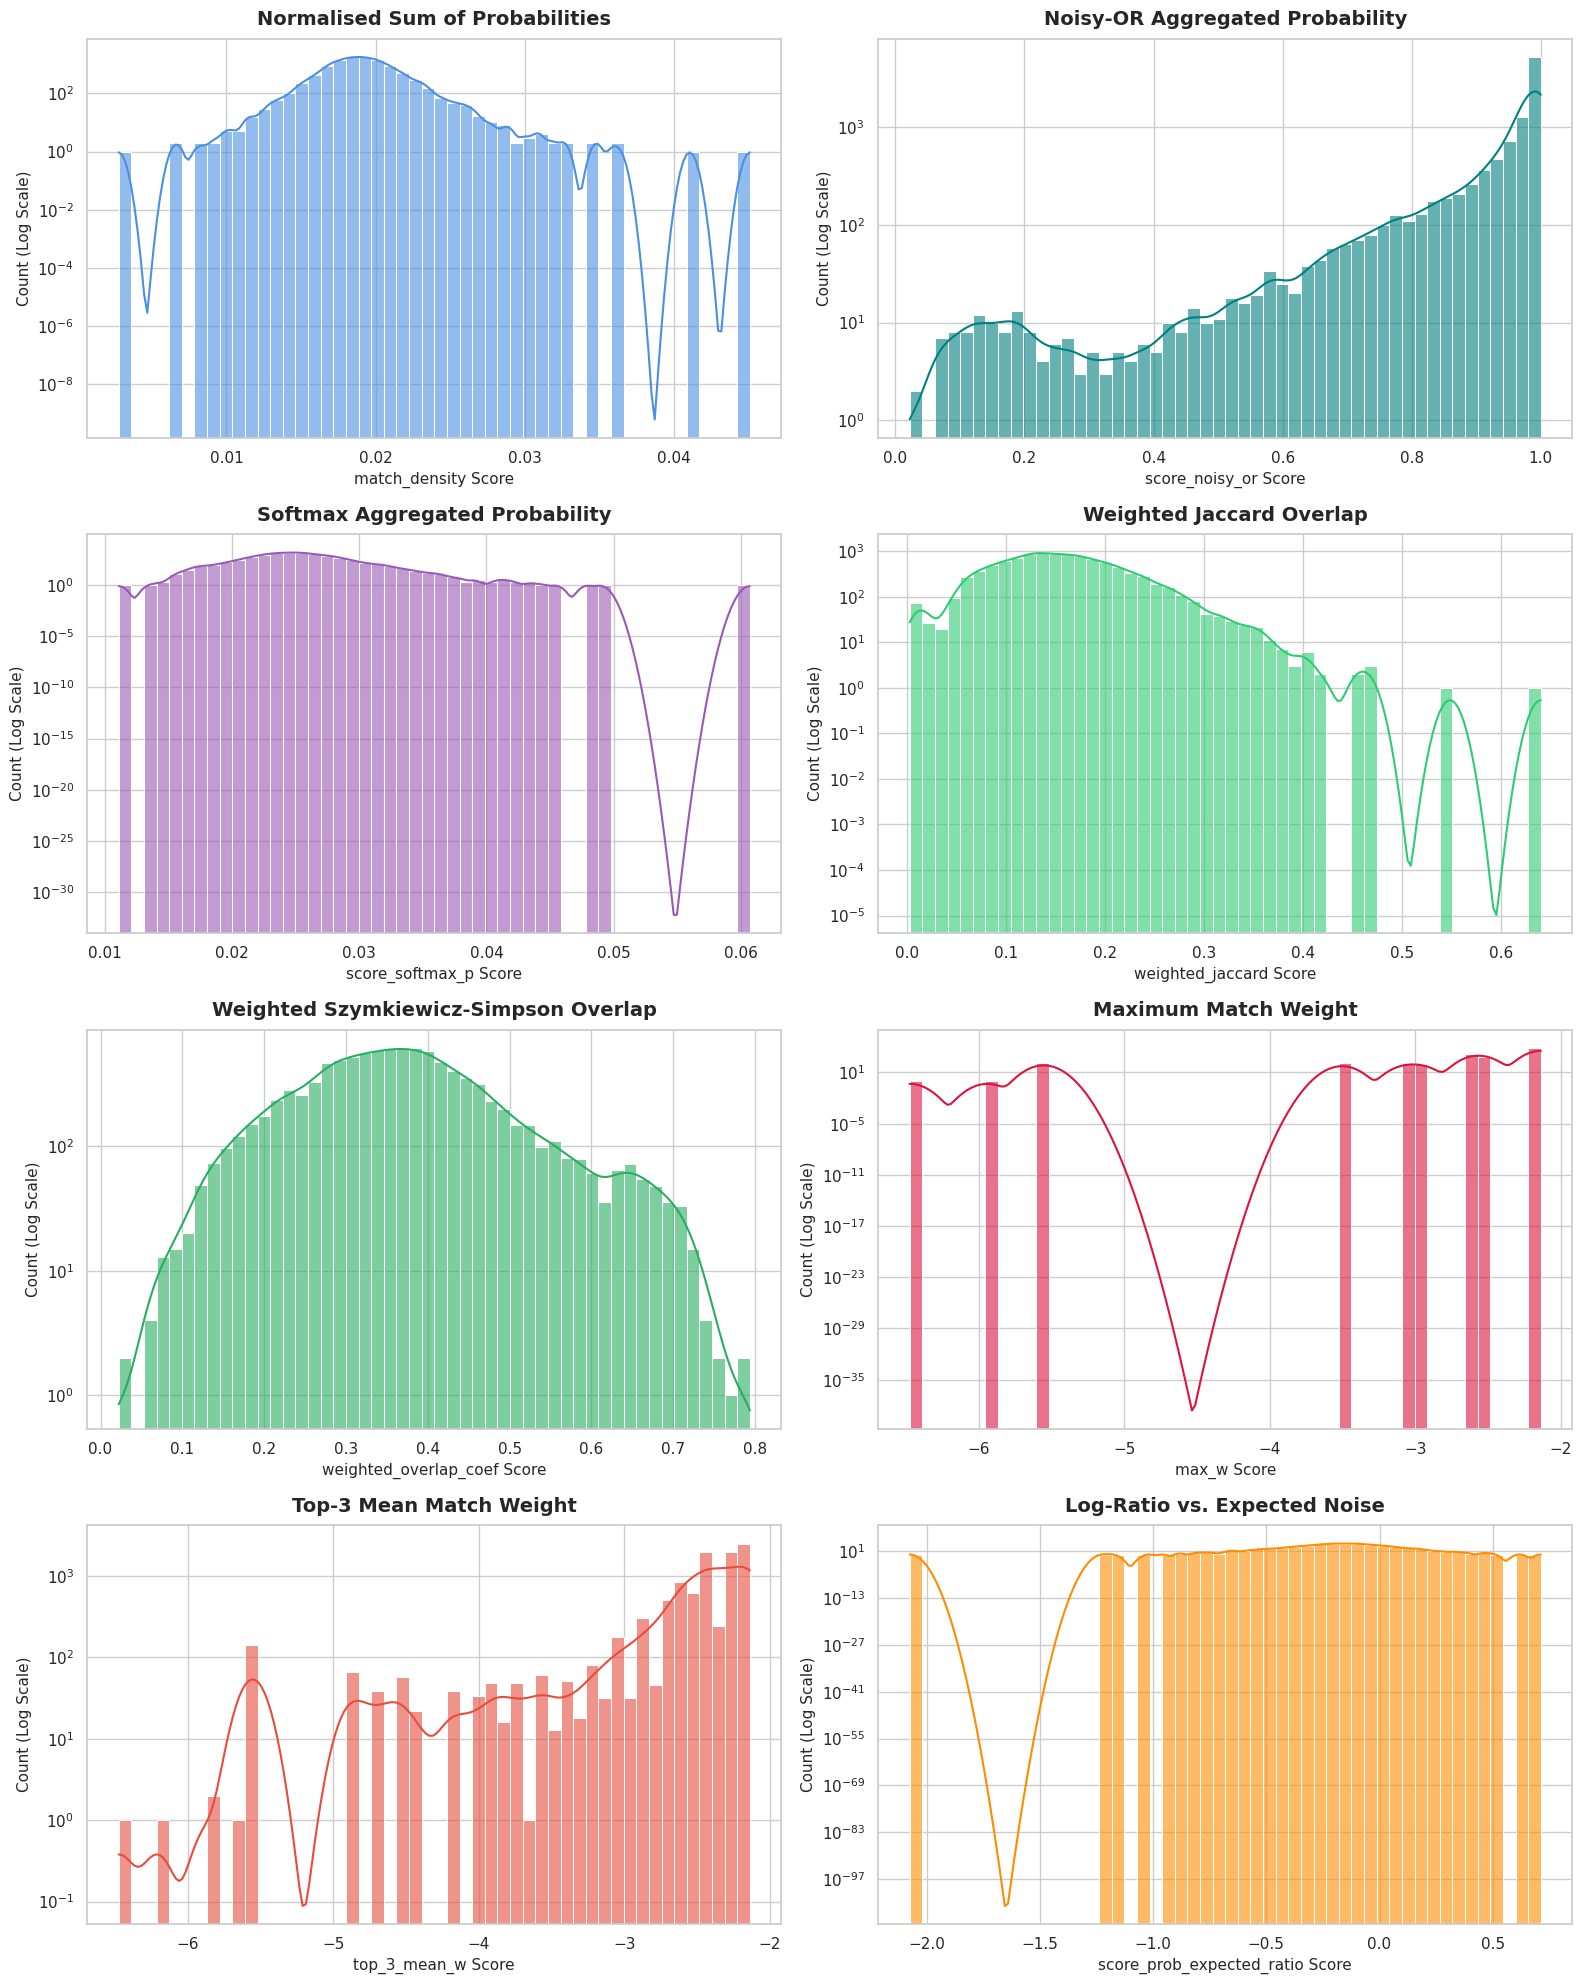

In [29]:
import math
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# Set a clean, professional aesthetic for the charts
sns.set_theme(style="whitegrid")


def plot_score_distributions(df, log_scale_y=True):
    """Generates a dynamic grid of histogram plots for all structural and probabilistic aggregation metrics."""
    # Comprehensive mapping of all current metrics: (column_name, display_title, hex_color)
    metrics = [
        ("match_density", "Normalised Sum of Probabilities", "#4A90E2"),  # Royal Blue
        ("score_noisy_or", "Noisy-OR Aggregated Probability", "#008080"),  # Teal
        ("score_softmax_p", "Softmax Aggregated Probability", "#9B59B6"),  # Purple
        ("weighted_jaccard", "Weighted Jaccard Overlap", "#2ECC71"),  # Emerald Green
        ("weighted_overlap_coef", "Weighted Szymkiewicz-Simpson Overlap", "#27AE60"),  # Dark Green
        ("max_w", "Maximum Match Weight", "crimson"),
        ("top_3_mean_w", "Top-3 Mean Match Weight", "#E74C3C"),  # Soft Red
        ("score_prob_expected_ratio", "Log-Ratio vs. Expected Noise", "darkorange"),
    ]

    # Dynamically calculate grid layout dimensions (always 2 columns wide)
    n_metrics = len(metrics)
    n_cols = 2
    n_rows = math.ceil(n_metrics / n_cols)

    # Initialize the dynamic grid canvas
    fig, axes = plt.subplots(nrows=n_rows, ncols=n_cols, figsize=(16, 5 * n_rows))
    axes = axes.flatten()  # Flatten into a 1D array for straightforward looping

    for idx, (col_name, title, color) in enumerate(metrics):
        ax = axes[idx]
        
        if col_name not in df.columns:
            ax.text(
                0.5,
                0.5,
                f"Column '{col_name}'\nnot found in DataFrame",
                ha="center",
                va="center",
                fontsize=12,
                color="gray",
            )
            ax.set_title(title, fontsize=14, fontweight="bold")
            continue

        # Drop NaNs and infinite values for stable distribution plotting
        clean_series = df[col_name].dropna()
        clean_series = clean_series[~np.isinf(clean_series)]

        if clean_series.empty:
            ax.text(
                0.5,
                0.5,
                "No valid numeric data",
                ha="center",
                va="center",
                fontsize=12,
                color="gray",
            )
            ax.set_title(title, fontsize=14, fontweight="bold")
            continue

        # Plot the structural distribution curve and histograms
        sns.histplot(
            data=clean_series,
            ax=ax,
            bins=50,
            kde=True,
            color=color,
            edgecolor="white",
            alpha=0.6,
        )

        # Apply log scale on Y-axis to reveal tiny counts of genuine matches
        if log_scale_y:
            ax.set_yscale("log")
            ax.set_ylabel("Count (Log Scale)", fontsize=11)
        else:
            ax.set_ylabel("Count (Linear Scale)", fontsize=11)

        # Standardise labels and presentation
        ax.set_title(title, fontsize=14, fontweight="bold", pad=10)
        ax.set_xlabel(f"{col_name} Score", fontsize=11)

    # Clean up any unused subplots if the metrics count doesn't perfectly fill the grid
    for idx in range(n_metrics, len(axes)):
        fig.delaxes(axes[idx])

    plt.tight_layout()
    plt.show()


# --- Execute the Plotting Engine ---
# Toggle log_scale_y=False if you prefer standard linear counting charts
plot_score_distributions(agg_df, log_scale_y=True)


In [30]:
import numpy as np
import pandas as pd
from sklearn.metrics import f1_score, precision_score, recall_score

# Dictionary to hold the final evaluation summaries for each score metric
evaluation_results = {}

agg_df["is_true_match"] = (agg_df["local_source_id_l"] == agg_df["local_source_id_r"]).astype(int)

for score_col in score_cols:
    print(f"Evaluating metrics for score column: {score_col}")

    # Generate 30 evenly spaced thresholds between min and max of this score
    min_score = agg_df[score_col].min()
    max_score = agg_df[score_col].max()
    thresholds = np.linspace(min_score, max_score, 30)

    bin_records = []

    for i, thresh in enumerate(thresholds):
        # Predict 1 if score >= threshold, else 0
        y_pred = (agg_df[score_col] >= thresh).astype(int)
        y_true = agg_df["is_true_match"]

        # Calculate metrics (zero_division handling prevents warnings on empty bins)
        p = precision_score(y_true, y_pred, zero_division=0)
        r = recall_score(y_true, y_pred, zero_division=0)
        f1 = f1_score(y_true, y_pred, zero_division=0)
        tp = int(((y_pred == 1) & (y_true == 1)).sum())
        fp = int(((y_pred == 1) & (y_true == 0)).sum())

        bin_records.append(
            {
                "bin_index": i + 1,
                "threshold": thresh,
                "precision": p,
                "recall": r,
                "f1_score": f1,
                "true_positives": tp,
                "false_positives": fp,
            }
        )

    # Convert results for this specific score to a DataFrame
    evaluation_results[score_col] = pd.DataFrame(bin_records)

# --- 3. Example: How to View the Output ---
# To view the 30-bin performance chart for your new ratio metric:
print("\n--- 30-Bin Performance Table for match_density ---")
print(
    evaluation_results["score_prob_expected_ratio"].to_string(
        index=False, formatters={c: "{:,.4f}".format for c in ["threshold"]}
    )
)


Evaluating metrics for score column: score_prob_expected_ratio
Evaluating metrics for score column: score_noisy_or
Evaluating metrics for score column: score_softmax_p
Evaluating metrics for score column: weighted_jaccard
Evaluating metrics for score column: weighted_overlap_coef
Evaluating metrics for score column: top_3_mean_w

--- 30-Bin Performance Table for match_density ---
 bin_index threshold  precision  recall  f1_score  true_positives  false_positives
         1   -2.0745   0.002000    1.00  0.003992              20             9980
         2   -1.9784   0.002000    1.00  0.003992              20             9979
         3   -1.8823   0.002000    1.00  0.003992              20             9979
         4   -1.7862   0.002000    1.00  0.003992              20             9979
         5   -1.6901   0.002000    1.00  0.003992              20             9979
         6   -1.5940   0.002000    1.00  0.003992              20             9979
         7   -1.4979   0.002000    1

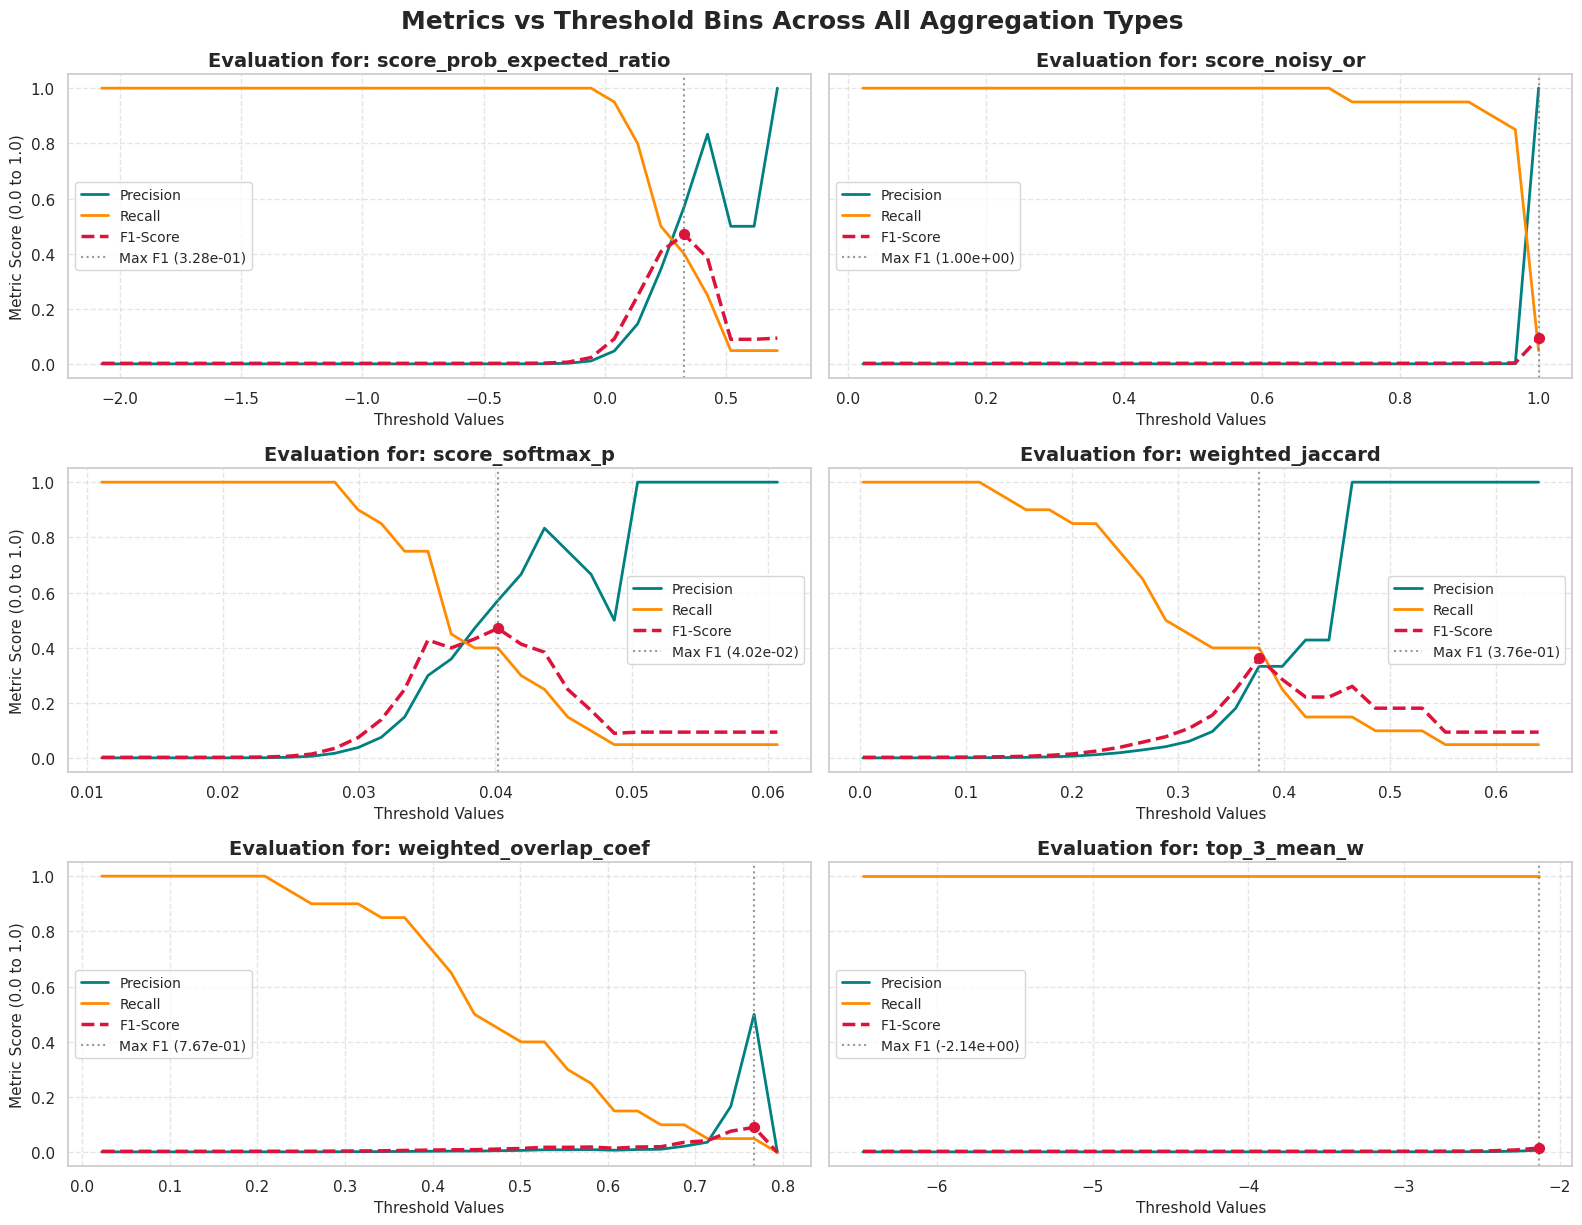

In [31]:
import matplotlib.pyplot as plt

# Create a 2x2 grid of subplots
fig, axes = plt.subplots(len(score_col)//4, 2, figsize=(16, 12), sharey=True)
axes = axes.flatten()  # Flatten into a 1D array for easy looping

for idx, score_col in enumerate(score_cols):
    ax = axes[idx]

    # Get the 30-bin results dataframe for this score
    res_df = evaluation_results[score_col]

    # Plot Precision, Recall, and F1-score
    ax.plot(
        res_df["threshold"],
        res_df["precision"],
        label="Precision",
        color="teal",
        linewidth=2,
    )
    ax.plot(
        res_df["threshold"],
        res_df["recall"],
        label="Recall",
        color="darkorange",
        linewidth=2,
    )
    ax.plot(
        res_df["threshold"],
        res_df["f1_score"],
        label="F1-Score",
        color="crimson",
        linewidth=2.5,
        linestyle="--",
    )

    # Highlight the peak F1-score threshold
    best_idx = res_df["f1_score"].idxmax()
    best_thresh = res_df.loc[best_idx, "threshold"]
    best_f1 = res_df.loc[best_idx, "f1_score"]

    ax.axvline(
        x=best_thresh,
        color="gray",
        linestyle=":",
        alpha=0.8,
        label=f"Max F1 ({best_thresh:.2e})",
    )
    ax.scatter(
        best_thresh, best_f1, color="crimson", s=50, zorder=5
    )  # Dot on the max F1 point

    # Subplot styling
    ax.set_title(f"Evaluation for: {score_col}", fontsize=14, weight="bold")
    ax.set_xlabel("Threshold Values", fontsize=11)
    if idx % 2 == 0:
        ax.set_ylabel("Metric Score (0.0 to 1.0)", fontsize=11)

    ax.grid(True, linestyle="--", alpha=0.5)
    ax.legend(loc="best", fontsize=10)
    ax.set_ylim(-0.05, 1.05)

# Adjust layout and render
plt.tight_layout()
plt.suptitle(
    "Metrics vs Threshold Bins Across All Aggregation Types",
    fontsize=18,
    weight="bold",
    y=1.02,
)
plt.show()


In [32]:
agg_df

,local_source_id_l,local_source_id_r,sum_p,max_w,top_3_mean_w,observed_edges,score_noisy_or,score_softmax_p,size_l,size_r,max_possible_pairs,match_density,weighted_jaccard,weighted_overlap_coef,score_prob_expected_ratio,is_true_match
1903,DF1_100037,DF1_100037,27.324891,-2.135931,-2.135931,990,1.000000,0.029015,35,35,1225,0.022306,0.640300,0.780711,0.008405,1
7303,DF1_100133,DF1_100037,21.509759,-2.135931,-2.135931,912,1.000000,0.024308,34,35,1190,0.018075,0.452930,0.632640,-0.201899,0
8603,DF1_100159,DF1_100037,18.777784,-2.135931,-2.135931,868,1.000000,0.022213,31,35,1085,0.017307,0.397647,0.605735,-0.245358,0
9003,DF1_100170,DF1_100037,18.324551,-2.135931,-2.135931,798,1.000000,0.023631,29,35,1015,0.018054,0.401190,0.631881,-0.203099,0
1916,DF1_100037,DF1_100151,19.969591,-2.135931,-2.135931,811,1.000000,0.025492,35,29,1015,0.019674,0.453541,0.688607,-0.117130,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9387,DF1_100173,DF2_100144,0.073640,-5.553982,-5.553982,4,0.071665,0.018428,1,5,5,0.014728,0.012426,0.073640,-0.406696,0
9384,DF1_100173,DF2_100140,0.027116,-5.942385,-6.208846,2,0.026938,0.013564,1,4,4,0.006779,0.005453,0.027116,-1.182605,0
9358,DF1_100173,DF2_100076,0.083368,-5.553982,-5.553982,4,0.080797,0.020842,1,4,4,0.020842,0.016956,0.083368,-0.059486,0
9354,DF1_100173,DF2_100065,0.073640,-5.553982,-5.553982,4,0.071665,0.018428,1,4,4,0.018410,0.014948,0.073640,-0.183555,0


Correlation Matrix:
                           score_prob_expected_ratio  score_noisy_or  \
score_prob_expected_ratio                   1.000000        0.332274   
score_noisy_or                              0.332274        1.000000   
score_softmax_p                             0.873918        0.258372   
weighted_jaccard                            0.336661        0.664773   
weighted_overlap_coef                       0.352910        0.555132   
top_3_mean_w                                0.563537        0.840142   

                           score_softmax_p  weighted_jaccard  \
score_prob_expected_ratio         0.873918          0.336661   
score_noisy_or                    0.258372          0.664773   
score_softmax_p                   1.000000          0.269840   
weighted_jaccard                  0.269840          1.000000   
weighted_overlap_coef             0.276830          0.658900   
top_3_mean_w                      0.537871          0.605664   

                          

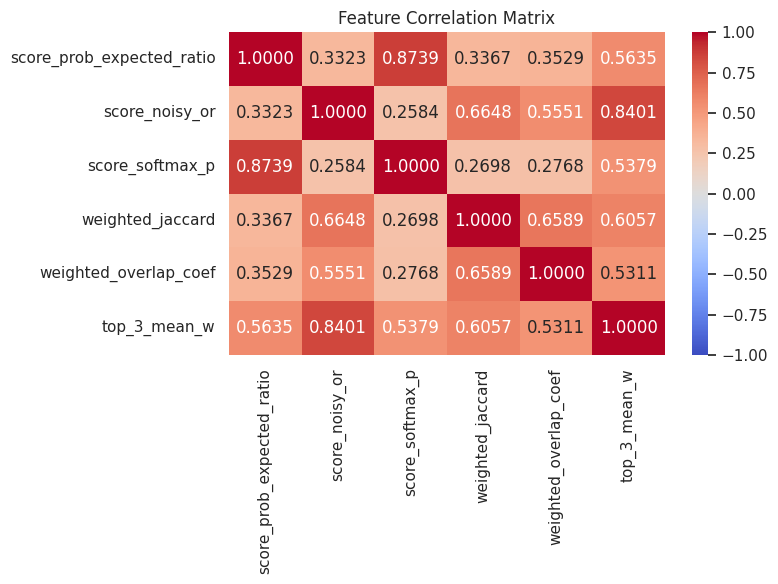

In [33]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Select the specific target columns from your DataFrame
corr_matrix = agg_df[score_cols].corr(method='pearson')

# 2. Print the text matrix to the console
print("Correlation Matrix:")
print(corr_matrix)

# 3. Optional: Create a clean visual heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".4f", vmin=-1, vmax=1)
plt.title('Feature Correlation Matrix')
plt.tight_layout()
plt.show()


In [34]:
import numpy as np
import pandas as pd

# --- 1. Define Features & Skewed Binning Strategy ---
features = [
    "score_prob_expected_ratio",
    "score_noisy_or",
    "score_softmax_p",
    "weighted_jaccard",
    "weighted_overlap_coef",
    "top_3_mean_w",
]


def create_skewed_bins(df, features):
    """Discretizes continuous metrics using robust, monotonically increasing bins."""
    binned_df = df.copy()

    for col in features:
        # Drop missing values to get clean boundaries
        clean_col = df[col].dropna()
        if clean_col.empty:
            binned_df[f"{col}_bin"] = 0
            continue

        min_v = clean_col.min()
        max_v = clean_col.max()

        # Handle columns with zero variance (all values are identical)
        if min_v == max_v:
            binned_df[f"{col}_bin"] = 0
            continue

        # Handle probabilities strictly bounded near 0 and 1
        if "score" in col or "weighted" in col:
            base_bins = [0.0, 0.2, 0.5, 0.75, 0.90, 0.95, 0.98, 1.0]
            # Clip base bins to the actual range of the data to keep it valid
            bins = [b for b in base_bins if min_v <= b <= max_v]
            
            # Ensure we have at least start and end anchors
            if len(bins) < 2:
                bins = [min_v, max_v]
        else:
            # For un-bounded ratios/weights, use quantiles heavily skewed toward the top
            quantiles = [0, 10, 25, 50, 75, 90, 95, 99, 100]
            bins = np.percentile(clean_col, quantiles)

        # Force structural array boundaries
        bins = np.array(bins)
        bins[0] = min_v
        bins[-1] = max_v

        # Critical Fixes: Deduplicate and force strict monotonic increasing sort order
        bins = np.unique(bins)
        bins = np.sort(bins)

        # Pad outer bounds slightly to absorb precision/rounding edge cases cleanly
        bins[0] -= 1e-5
        bins[-1] += 1e-5

        # Double check array validity before cutting
        if len(bins) >= 2 and np.all(np.diff(bins) > 0):
            binned_df[f"{col}_bin"] = pd.cut(
                df[col], bins=bins, labels=False, include_lowest=True
            )
        else:
            # Fallback for degenerate distributions
            binned_df[f"{col}_bin"] = 0

    return binned_df


# --- 2. Custom EM Parameter Training Block ---
def train_fellegi_sunter_parameters(df, features):
    """Computes empirical m (match) and u (non-match) conditional probability tables."""
    param_dict = {}

    # Prior probability of two entities matching in this profile space
    p_match = df["is_true_match"].mean()

    for col in features:
        bin_col = f"{col}_bin"

        # Calculate P(Bin | True Match) -> m-probability
        m_probs = (
            df[df["is_true_match"] == 1][bin_col].value_counts(normalize=True)
        )

        # Calculate P(Bin | Non Match) -> u-probability
        u_probs = (
            df[df["is_true_match"] == 0][bin_col].value_counts(normalize=True)
        )

        # Reindex to ensure all active bins are cleanly populated
        all_bins = df[bin_col].unique()
        m_probs = m_probs.reindex(all_bins, fill_value=1e-6)
        u_probs = u_probs.reindex(all_bins, fill_value=1e-6)

        param_dict[col] = {"m": m_probs.to_dict(), "u": u_probs.to_dict()}

    return param_dict, p_match


# --- 3. Correlation Weight Adjustment Calculations ---
# Build your provided correlation matrix explicit definition
corr_data = {
    "score_prob_expected_ratio": [
        1.000000,
        0.277956,
        0.891613,
        0.330161,
        0.381648,
        0.529656,
    ],
    "score_noisy_or": [
        0.277956,
        1.000000,
        0.211340,
        0.689533,
        0.568031,
        0.831891,
    ],
    "score_softmax_p": [
        0.891613,
        0.211340,
        1.000000,
        0.274489,
        0.315059,
        0.499795,
    ],
    "weighted_jaccard": [
        0.330161,
        0.689533,
        0.274489,
        1.000000,
        0.644627,
        0.572959,
    ],
    "weighted_overlap_coef": [
        0.381648,
        0.568031,
        0.315059,
        0.644627,
        1.000000,
        0.510392,
    ],
    "top_3_mean_w": [
        0.529656,
        0.831891,
        0.499795,
        0.572959,
        0.510392,
        1.000000,
    ],
}
corr_df = pd.DataFrame(corr_data, index=features)

# Compute Independence Penalty: Higher average correlation = lower standalone weight
# We exclude the diagonal element (correlation with self = 1.0)
avg_correlation = (corr_df.sum() - 1.0) / (len(features) - 1)
feature_weights = 1.0 - avg_correlation  # Lower correlation maps to high feature weight


# --- 4. Predict and Calculate Redundancy-Penalized Post Weights ---
def predict_adjusted_match_probabilities(df, params, prior_p, weights):
    """Calculates Fellegi-Sunter post weights adjusted for feature redundancy."""
    # Convert baseline prior match rate to starting odds log frame
    log_prior_odds = np.log(prior_p / (1.0 - prior_p))
    total_log_odds = np.zeros(len(df)) + log_prior_odds

    for col in features:
        bin_col = f"{col}_bin"
        w_adjustment = weights[col]  # Our correlation dampener

        # Retrieve m and u parameters mapped to actual runtime record series bins
        m_val = df[bin_col].map(params[col]["m"]).fillna(1e-6)
        u_val = df[bin_col].map(params[col]["u"]).fillna(1e-6)

        # Calculate standard Bayes Factor match weight
        bayes_factor_weight = np.log(m_val / u_val)

        # Apply correlation dampening logic to penalized double counting
        total_log_odds += bayes_factor_weight * w_adjustment

    # Transform aggregated logs back into exact bounded Match Probabilities
    odds = np.exp(total_log_odds)
    df["final_adjusted_prob"] = odds / (1.0 + odds)
    return df


# --- Execution Flow Run ---
binned_agg_df = create_skewed_bins(agg_df, features)
model_params, prior_p_match = train_fellegi_sunter_parameters(
    binned_agg_df, features
)

final_scored_df = predict_adjusted_match_probabilities(
    binned_agg_df, model_params, prior_p_match, feature_weights
)

# Preview high-scoring results against original target indicators
print(
    final_scored_df[
        ["local_source_id_l", "local_source_id_r", "final_adjusted_prob", "is_true_match"]
    ].head()
)


     local_source_id_l local_source_id_r  final_adjusted_prob  is_true_match
1903        DF1_100037        DF1_100037             0.003506              1
7303        DF1_100133        DF1_100037             0.003506              0
8603        DF1_100159        DF1_100037             0.003506              0
9003        DF1_100170        DF1_100037             0.003506              0
1916        DF1_100037        DF1_100151             0.003506              0


In [35]:
import numpy as np
import pandas as pd

# --- 1. Core Feature Specification ---
features = [
    "score_prob_expected_ratio",
    "score_noisy_or",
    "score_softmax_p",
    "weighted_jaccard",
    "weighted_overlap_coef",
    "top_3_mean_w",
]

# --- 2. Robust Monotonic Binning Engine ---
def create_skewed_bins(df, features):
    """Discretizes continuous metrics using strictly monotonic, safe boundaries."""
    binned_df = df.copy()

    for col in features:
        clean_col = df[col].dropna()
        if clean_col.empty:
            binned_df[f"{col}_bin"] = 0
            continue

        min_v = float(clean_col.min())
        max_v = float(clean_col.max())

        # Guard against zero-variance columns
        if min_v == max_v:
            binned_df[f"{col}_bin"] = 0
            continue

        # Handle probabilities/scores strictly bounded near 0 and 1
        if "score" in col or "weighted" in col:
            base_bins = [0.0, 0.2, 0.5, 0.75, 0.90, 0.95, 0.98, 1.0]
            bins = [b for b in base_bins if min_v <= b <= max_v]
            if len(bins) < 2:
                bins = [min_v, max_v]
        else:
            # Skewed quantile logic for un-bounded weights/ratios
            quantiles = [0, 20, 40, 60, 80, 90, 95, 100]
            bins = np.percentile(clean_col, quantiles)

        # Force outer boundaries explicitly
        bins = np.array(bins, dtype=float)
        bins[0] = min_v
        bins[-1] = max_v

        # Deduplicate overlapping thresholds and force chronological ascending sort
        bins = np.unique(bins)
        bins = np.sort(bins)

        # Pad outer bounds slightly to safely absorb rounding/floating-point drift
        bins[0] -= 1e-5
        bins[-1] += 1e-5

        # Execute safe cut if bins remain structurally valid
        if len(bins) >= 2 and np.all(np.diff(bins) > 0):
            binned_df[f"{col}_bin"] = pd.cut(
                df[col], bins=bins, labels=False, include_lowest=True
            )
        else:
            binned_df[f"{col}_bin"] = 0

    return binned_df


# --- 3. Custom Parameter Training Block ---
def train_fellegi_sunter_parameters(df, features):
    """Computes conditional m (match) and u (non-match) probability distributions."""
    param_dict = {}
    
    # Calculate baseline match prior rate from training labels
    p_match = float(df["is_true_match"].mean())
    if p_match == 0:  # Fallback guard if dataset lacks labels
        p_match = 0.01

    for col in features:
        bin_col = f"{col}_bin"
        all_active_bins = df[bin_col].dropna().unique()

        # Extract P(Bin | True Match) -> m-probability
        m_subset = df[df["is_true_match"] == 1][bin_col]
        if not m_subset.empty:
            m_probs = m_subset.value_counts(normalize=True).reindex(all_active_bins, fill_value=1e-6)
        else:
            m_probs = pd.Series(1.0 / len(all_active_bins), index=all_active_bins)

        # Extract P(Bin | Non Match) -> u-probability
        u_subset = df[df["is_true_match"] == 0][bin_col]
        if not u_subset.empty:
            u_probs = u_subset.value_counts(normalize=True).reindex(all_active_bins, fill_value=1e-6)
        else:
            u_probs = pd.Series(1.0 / len(all_active_bins), index=all_active_bins)

        param_dict[col] = {"m": m_probs.to_dict(), "u": u_probs.to_dict()}

    return param_dict, p_match


# --- 4. Hardcoded Correlation Matrix Definition ---
corr_data = {
    "score_prob_expected_ratio": [1.000000, 0.277956, 0.891613, 0.330161, 0.381648, 0.529656],
    "score_noisy_or":           [0.277956, 1.000000, 0.211340, 0.689533, 0.568031, 0.831891],
    "score_softmax_p":          [0.891613, 0.211340, 1.000000, 0.274489, 0.315059, 0.499795],
    "weighted_jaccard":         [0.330161, 0.689533, 0.274489, 1.000000, 0.644627, 0.572959],
    "weighted_overlap_coef":    [0.381648, 0.568031, 0.315059, 0.644627, 1.000000, 0.510392],
    "top_3_mean_w":             [0.529656, 0.831891, 0.499795, 0.572959, 0.510392, 1.000000],
}
corr_df = pd.DataFrame(corr_data, index=features)

# Compute Independence Penalty (Lower average correlation = higher standalone feature weight)
avg_correlation = (corr_df.sum() - 1.0) / (len(features) - 1)
feature_weights = 1.0 - avg_correlation


# --- 5. Predict and Execute Adjusted Probability Calculations ---
def predict_adjusted_match_probabilities(df, params, prior_p, weights):
    """Aggregates log-odds utilizing correlation-penalized feature contribution factors."""
    # Convert base prior to starting log odds space
    prior_p = np.clip(prior_p, 1e-6, 1.0 - 1e-6)
    log_prior_odds = np.log(prior_p / (1.0 - prior_p))
    total_log_odds = np.zeros(len(df)) + log_prior_odds

    for col in features:
        bin_col = f"{col}_bin"
        w_adjustment = weights[col]  # Damping weight factor

        # Map trained conditional mappings back onto columns safely
        m_val = df[bin_col].map(params[col]["m"]).fillna(1e-6).astype(float)
        u_val = df[bin_col].map(params[col]["u"]).fillna(1e-6).astype(float)

        # Standard Fellegi-Sunter log-odds calculation
        bayes_factor_weight = np.log(m_val / u_val)

        # Apply independence penalty modifier directly to log space contribution
        total_log_odds += bayes_factor_weight * w_adjustment

    # Un-log cumulative scores back into true bounded probability space
    odds = np.exp(total_log_odds)
    df["final_adjusted_prob"] = odds / (1.0 + odds)
    return df


# --- 6. Pipeline Execution Execution Trigger ---
# Run binning transformations safely
binned_agg_df = create_skewed_bins(agg_df, features)

# Build conditional weight profile mappings
model_params, prior_p_match = train_fellegi_sunter_parameters(binned_agg_df, features)

# Generate final outputs
final_scored_df = predict_adjusted_match_probabilities(
    binned_agg_df, model_params, prior_p_match, feature_weights
)

# Inspect high-probability predictions alongside empirical labels
print("--- Scored Output Overview ---")
print(
    final_scored_df[
        ["local_source_id_l", "local_source_id_r", "final_adjusted_prob", "is_true_match"]
    ].head(10)
)


--- Scored Output Overview ---
     local_source_id_l local_source_id_r  final_adjusted_prob  is_true_match
1903        DF1_100037        DF1_100037             0.004125              1
7303        DF1_100133        DF1_100037             0.004125              0
8603        DF1_100159        DF1_100037             0.004125              0
9003        DF1_100170        DF1_100037             0.004125              0
1916        DF1_100037        DF1_100151             0.004125              0
9203        DF1_100172        DF1_100037             0.004125              0
1603        DF1_100028        DF1_100037             0.004125              0
8103        DF1_100151        DF1_100037             0.004125              0
7316        DF1_100133        DF1_100151             0.004125              0
5903        DF1_100107        DF1_100037             0.004125              0


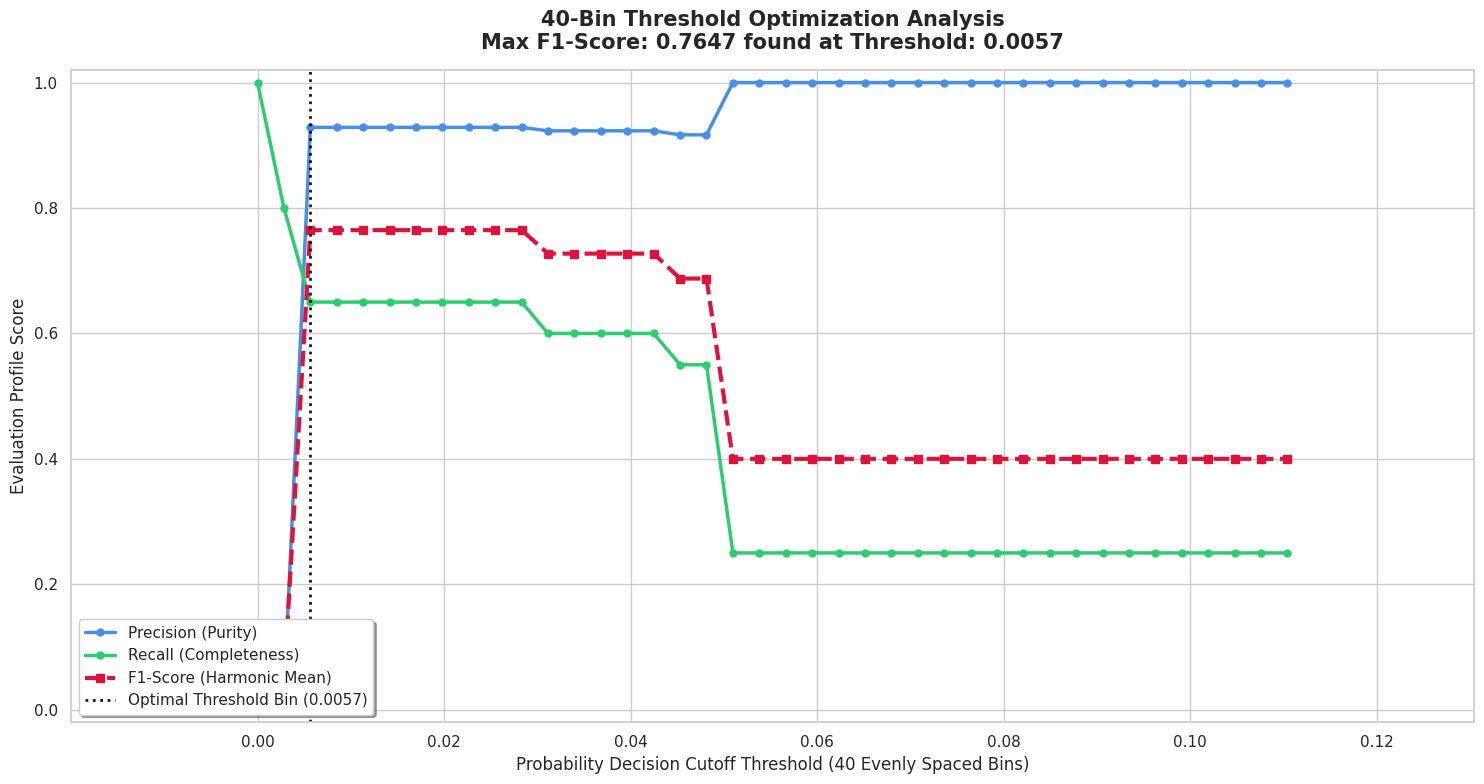

In [36]:
import numpy as np
import pandas as pd
from sklearn.metrics import precision_score, recall_score, f1_score

# Clean diagnostic frame setup
clean_df = final_scored_df[["final_adjusted_prob", "is_true_match"]].dropna()
y_true = clean_df["is_true_match"].astype(int).values
y_scores = clean_df["final_adjusted_prob"].values

if len(np.unique(y_true)) > 1:
    # Set boundaries based on actual min and max predictions
    min_score = float(y_scores.min())
    max_score = float(y_scores.max())
    
    # Generate exactly 40 evenly-spaced threshold steps
    eval_thresholds = np.linspace(min_score, max_score, 40)
    
    # Arrays to record performance metrics at each step
    prec_list = []
    rec_list = []
    f1_list = []
    
    # Explicit loop across all 40 bin thresholds
    for t in eval_thresholds:
        y_pred = (y_scores >= t).astype(int)
        
        # Calculate scores using zero_division=0 to prevent NaN crashes at boundary limits
        prec_list.append(precision_score(y_true, y_pred, zero_division=0))
        rec_list.append(recall_score(y_true, y_pred, zero_division=0))
        f1_list.append(f1_score(y_true, y_pred, zero_division=0))
        
    # Find the threshold value out of the 40 bins that maximizes your F1-Score
    best_idx = np.argmax(f1_list)
    best_threshold = eval_thresholds[best_idx]
    best_f1 = f1_list[best_idx]
    
    # 2. Create a separate large canvas for the 40-Bin Threshold Curve
    plt.figure(figsize=(15, 8))
    
    # Plot markers ('o-') to clearly visualize the discrete 40 bin evaluation points
    plt.plot(eval_thresholds, prec_list, 'o-', label="Precision (Purity)", color="#4A90E2", linewidth=2.5, markersize=5)
    plt.plot(eval_thresholds, rec_list, 'o-', label="Recall (Completeness)", color="#2ECC71", linewidth=2.5, markersize=5)
    plt.plot(eval_thresholds, f1_list, 's--', label="F1-Score (Harmonic Mean)", color="crimson", linewidth=3, markersize=6)
    
    # Highlight the optimal bin boundary anchor line
    plt.axvline(x=best_threshold, color="black", linestyle=":", alpha=0.9, 
                linewidth=2, label=f"Optimal Threshold Bin ({best_threshold:.4f})")
    
    plt.title(f"40-Bin Threshold Optimization Analysis\nMax F1-Score: {best_f1:.4f} found at Threshold: {best_threshold:.4f}", 
              fontsize=15, fontweight="bold", pad=15)
    plt.xlabel("Probability Decision Cutoff Threshold (40 Evenly Spaced Bins)", fontsize=12)
    plt.ylabel("Evaluation Profile Score", fontsize=12)
    plt.xlim(min_score - 0.02, max_score + 0.02)
    plt.ylim(-0.02, 1.02)
    plt.legend(loc="lower left", frameon=True, shadow=True, fontsize=11)
    plt.tight_layout()
    plt.show()

else:
    print("Execution Error: Labeled input column 'is_true_match' must contain a mix of both matching and non-matching entries.")


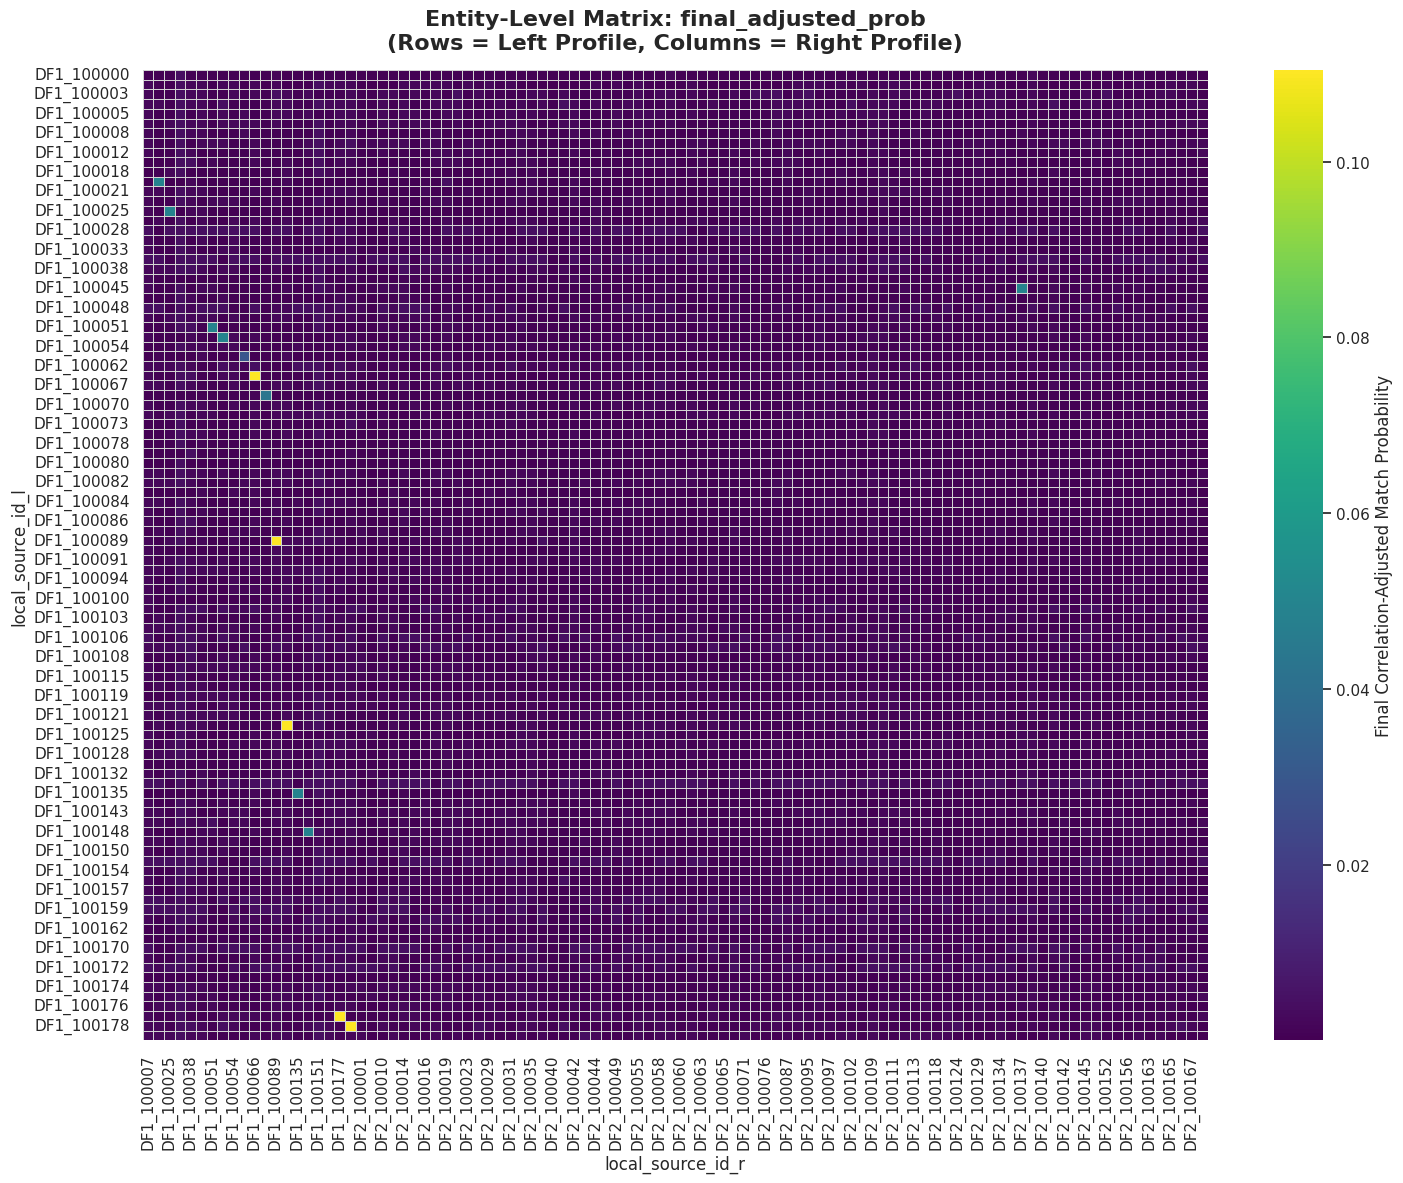

In [37]:
import matplotlib.pyplot as plt
import seaborn as sns

# Clean, professional theme setting
sns.set_theme(style="whitegrid")

# Pivot out the final correlation-adjusted probability mapping
mat_final = final_scored_df.pivot(
    index="local_source_id_l", columns="local_source_id_r", values="final_adjusted_prob"
)

# 1. Create a large, high-resolution canvas for the Heatmap
plt.figure(figsize=(15, 12))

sns.heatmap(
    mat_final,
    cmap="viridis",
    vmin=min_score,
    vmax=max_score,
    mask=mat_final.isna(),  # Hide missing evaluation pairs safely
    linewidths=0.5,
    linecolor="lightgray",
    cbar_kws={'label': 'Final Correlation-Adjusted Match Probability'}
)

plt.title("Entity-Level Matrix: final_adjusted_prob\n(Rows = Left Profile, Columns = Right Profile)", 
          fontsize=16, fontweight="bold", pad=15)
plt.xlabel("local_source_id_r", fontsize=12)
plt.ylabel("local_source_id_l", fontsize=12)
plt.tight_layout()
plt.show()
